# Modelado de las series S1, S2 y S6

## Resumen técnico

Se evaluaron **S1 — La Aurora**, **S2 — Valle Nuevo** y **S6 — Guatemala** con
la misma partición temporal usada por el resto del equipo: 147 meses de
entrenamiento y 63 de prueba. En S1 el menor error correspondió a
**ARIMA(1,1,1)** (RMSE 38,251); en S2, a **Prophet** (RMSE 23,187); en S6, a
**SARIMA(1,1,1)(0,1,1,12)** (RMSE 47,260).

S6 requiere una lectura distinta a las otras dos series. Sus 42 meses en cero,
entre enero de 2023 y junio de 2026, caen enteramente dentro del conjunto de
prueba y responden a que Guatemala deja de reportarse como categoría
individual de `País` después del cambio de granularidad, no a una caída real
del movimiento migratorio. Además, estos registros corresponden
principalmente a residentes guatemaltecos que regresan al país, por lo que no
deben leerse como turismo extranjero.

## Contexto y métodos

### Supuestos principales

- Las series tienen frecuencia mensual (`MS`) y período estacional de 12.
- El entrenamiento cubre enero de 2009 a marzo de 2021 (147 meses); ninguna de
  las tres series tiene ceros en ese tramo.
- La prueba cubre abril de 2021 a junio de 2026 (63 meses).
- Las transformaciones, parámetros y ajustes solo usan entrenamiento.
- MAE y RMSE comparan todos los modelos sobre los mismos 63 meses.
- AIC y BIC se reportan únicamente para ARIMA/SARIMA.
- MAPE excluye meses cuyo valor real sea cero. En S6 esto descarta los 42
  ceros de prueba; el MAPE de S6 solo describe los 21 meses de prueba con
  valor distinto de cero y debe interpretarse con esa limitación.

Se comparan candidatos ARIMA/SARIMA manuales, la sugerencia acotada de
`auto_arima`, Prophet, Holt-Winters, suavizamiento exponencial simple y
Seasonal Naive. Prophet se ajusta con el módulo propio de esta entrega,
`src/modelos_prophet.py`. Holt-Winters, suavizamiento simple y Seasonal Naive
se ejecutan con adaptadores autónomos dentro de
`src/modelado_s1_s2_s6.py`, con la misma configuración aplicada al resto
de las series. Un candidato
inestable permanece en la tabla de métricas para mostrar por qué fue
descartado, en vez de ocultarse.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

RAIZ = Path.cwd().resolve()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

from modelado_s1_s2_s6 import ejecutar_modelado_s1_s2_s6

resultados = ejecutar_modelado_s1_s2_s6(guardar=True, generar_figuras=True)
metricas = pd.read_csv(RAIZ / "data" / "processed" / "resultados" / "metricas_s1_s2_s6.csv")
estacionariedad = pd.read_csv(
    RAIZ / "data" / "processed" / "resultados" / "estacionariedad_s1_s2_s6.csv"
)
DIR_IMG = RAIZ / "informe" / "img" / "final"

NOMBRES = ["S1_la_aurora", "S2_valle_nuevo", "S6_guatemala"]

validacion = pd.DataFrame({
    "serie": ["S1", "S2", "S6"],
    "meses_total": [len(resultados[n]["serie"]) for n in NOMBRES],
    "meses_train": [len(resultados[n]["train"]) for n in NOMBRES],
    "meses_test": [len(resultados[n]["test"]) for n in NOMBRES],
    "ceros_train": [resultados[n]["resumen"]["ceros_train"] for n in NOMBRES],
    "ceros_test": [resultados[n]["resumen"]["ceros_test"] for n in NOMBRES],
    "pronosticos_por_modelo": [len(resultados[n]["test"]) for n in NOMBRES],
})
validacion

09:53:06 - cmdstanpy - INFO - Chain [1] start processing


09:53:06 - cmdstanpy - INFO - Chain [1] done processing


09:53:10 - cmdstanpy - INFO - Chain [1] start processing


09:53:10 - cmdstanpy - INFO - Chain [1] done processing


09:53:17 - cmdstanpy - INFO - Chain [1] start processing


09:53:17 - cmdstanpy - INFO - Chain [1] done processing


,serie,meses_total,meses_train,meses_test,ceros_train,ceros_test,pronosticos_por_modelo
0,S1,210,147,63,0,0,63
1,S2,210,147,63,0,0,63
2,S6,210,147,63,0,42,63


## S1 — La Aurora

S1 contiene 210 meses, desde enero de 2009 hasta junio de 2026, sin meses en
cero. Este análisis reutiliza y valida las cifras del avance: fuerza de
tendencia 0.811 y fuerza estacional 0.559. La Aurora es la principal frontera
aérea del país y su comportamiento antes de 2020 combina crecimiento sostenido
con picos anuales.

### La partición deja la recuperación dentro de la prueba

Igual que en S0 y S5, la franja amarilla marca la pandemia y la línea roja
señala el inicio de la prueba. La caída de 2020 lleva a La Aurora a un mínimo
de 484 viajeros en abril de ese año, una ruptura extraordinaria que no se
repite en el resto de la serie.

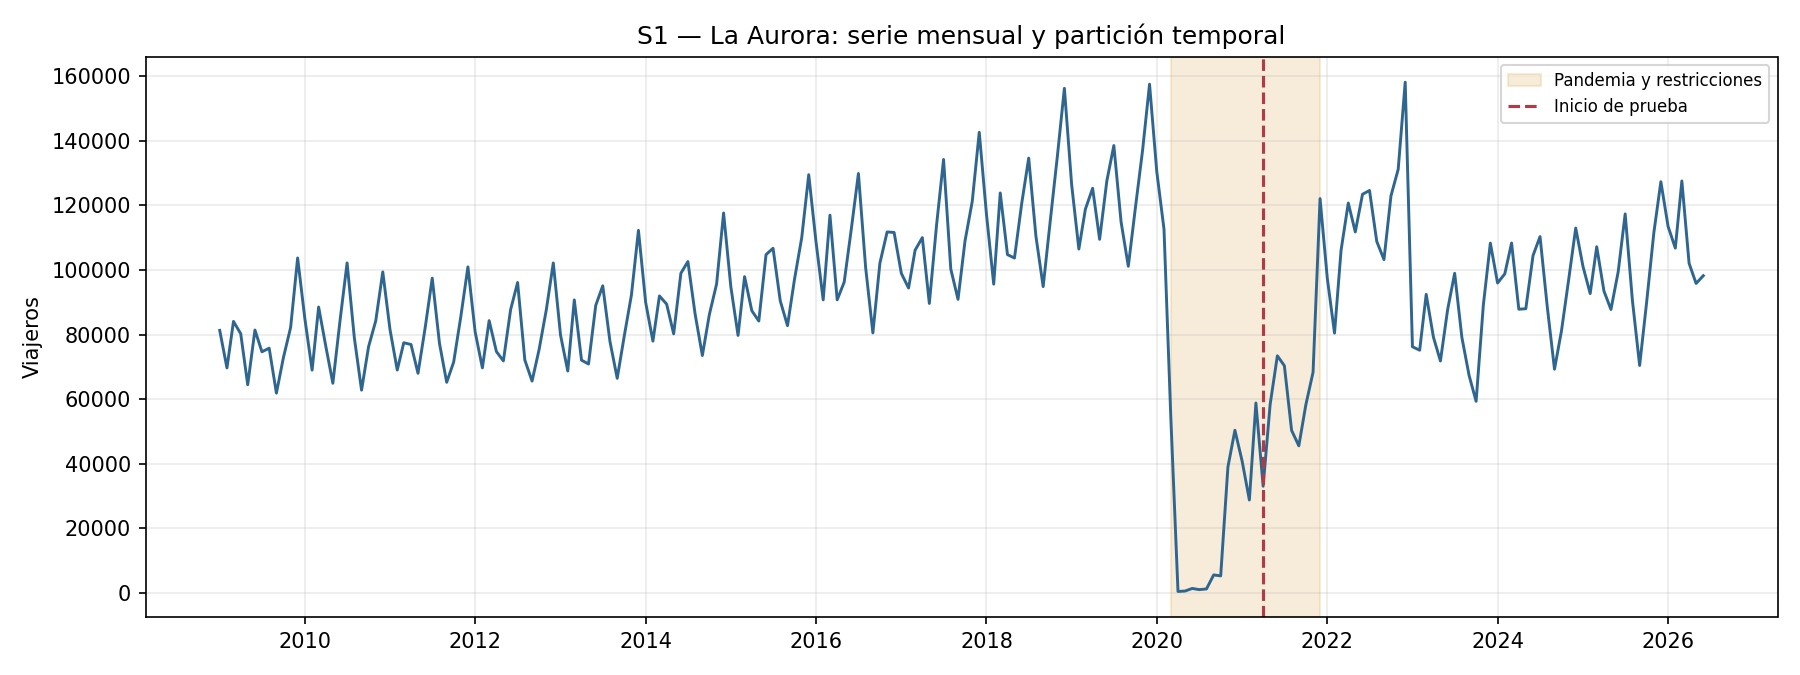

In [2]:
display(Image(filename=str(DIR_IMG / "s1_serie_particion.png")))

### La tendencia domina sobre una estacionalidad todavía marcada

Con fuerza de tendencia 0.811 y fuerza estacional 0.559, La
Aurora muestra un patrón más estacional que S0, coherente con los picos de
temporada alta del tráfico aéreo. El residuo de la descomposición se dispara
alrededor de 2020 por el mismo motivo que en las demás series: un cierre tan
abrupto no es un patrón estacional normal.

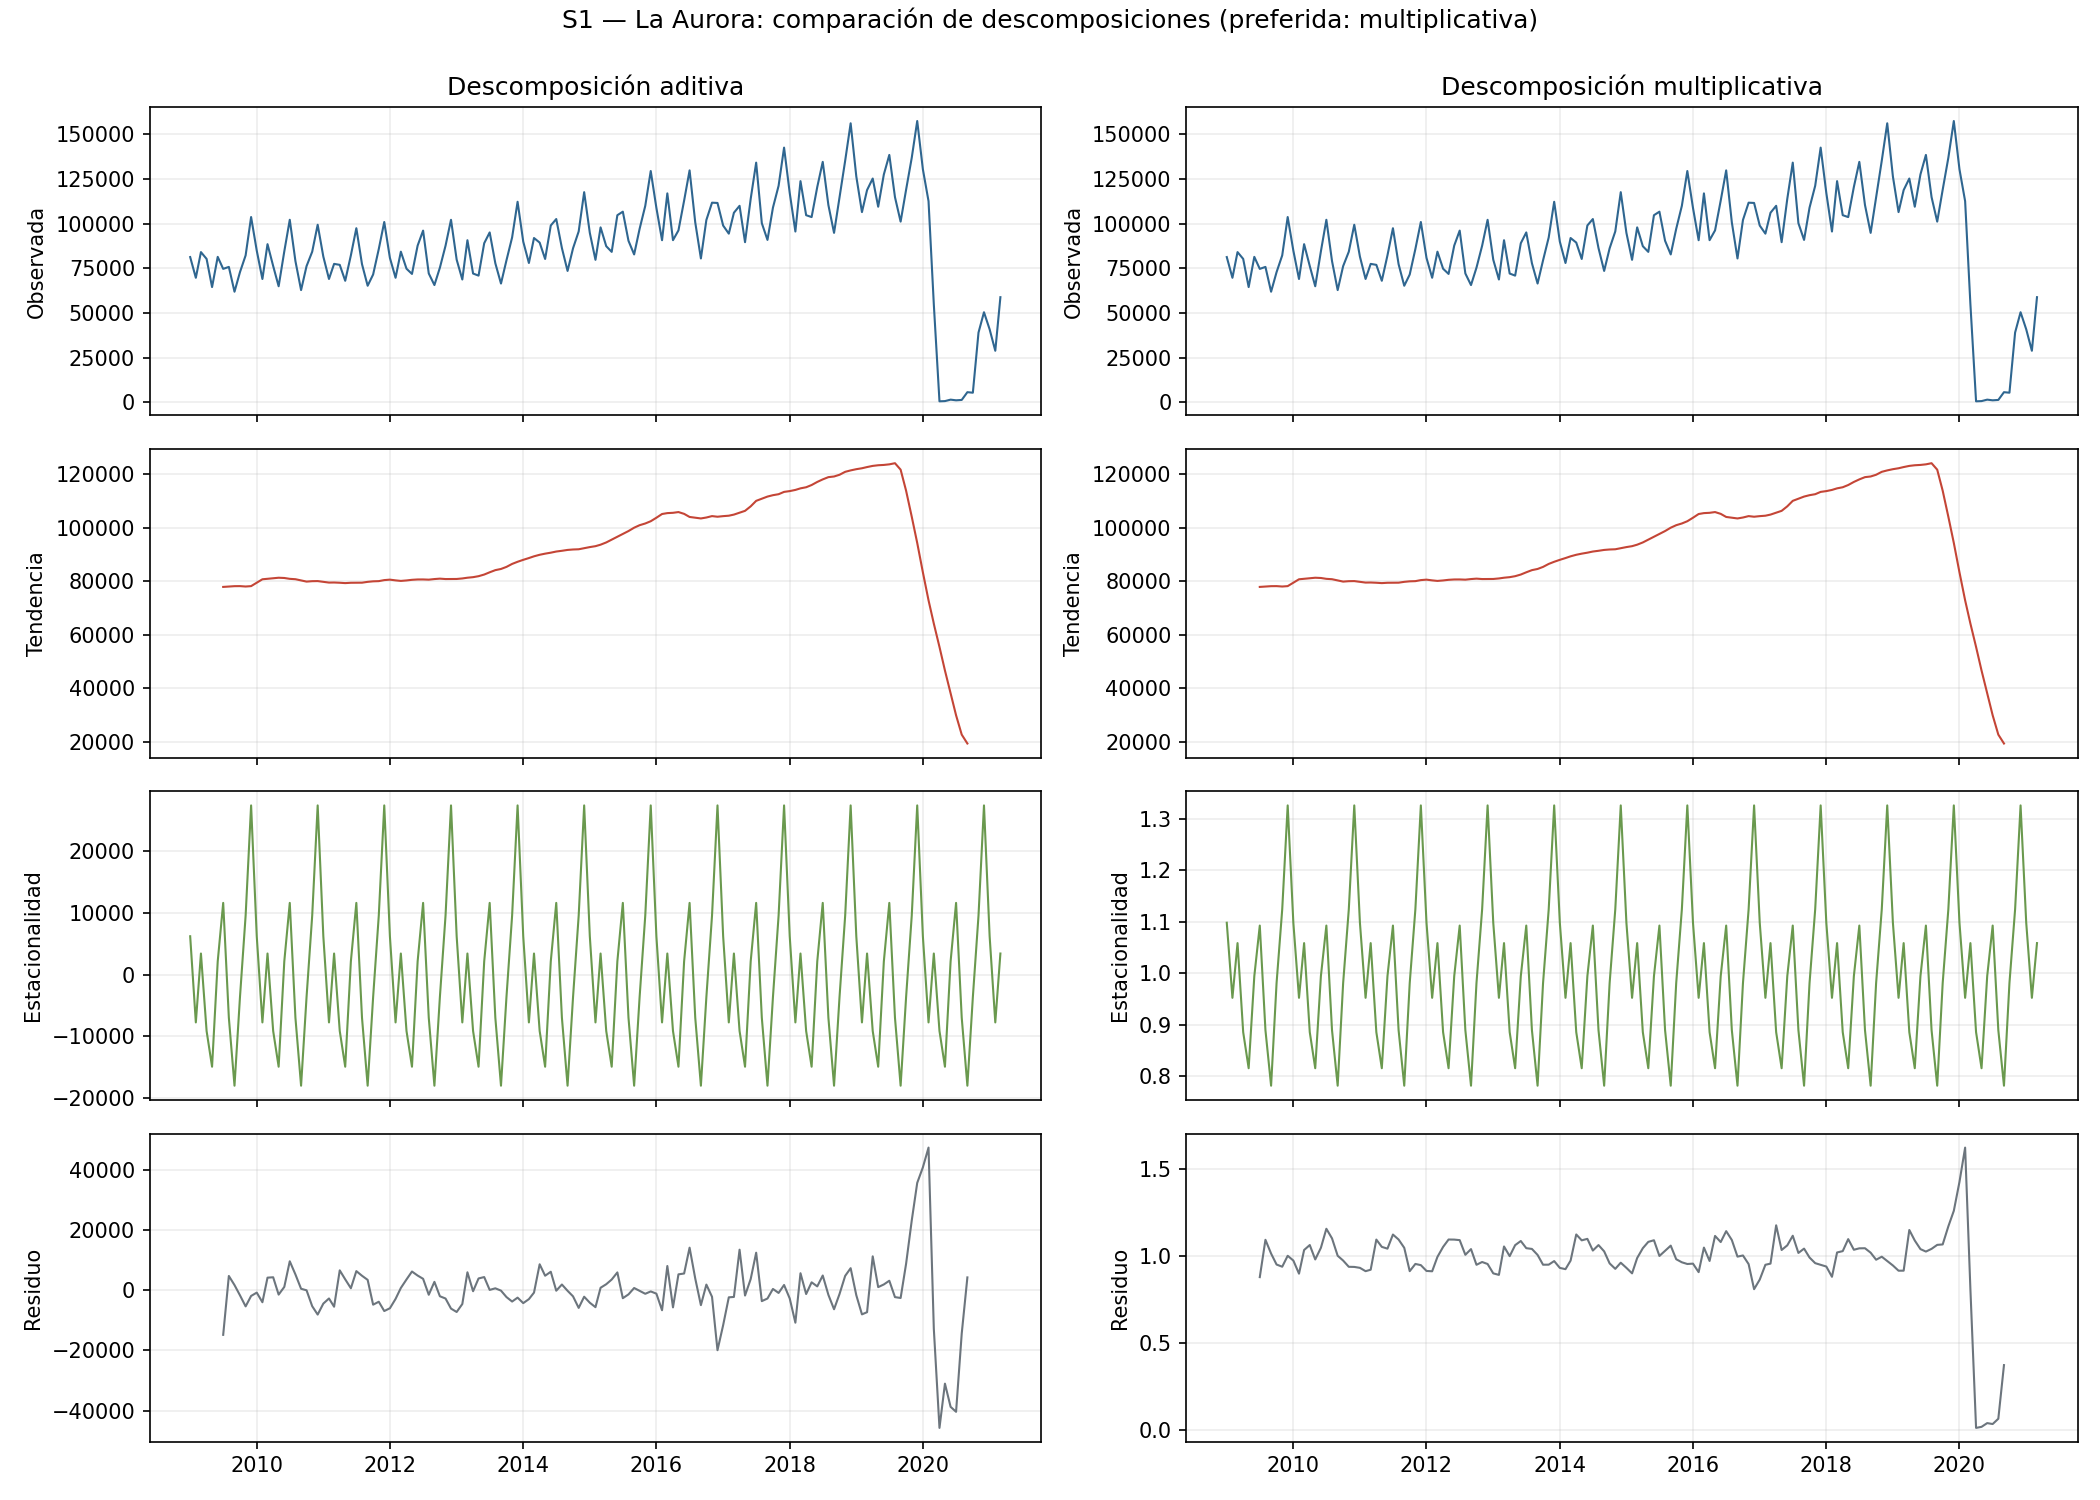

In [3]:
display(Image(filename=str(DIR_IMG / "s1_descomposicion.png")))

### El logaritmo es válido porque S1 no tiene ceros

Como todos los valores de S1 son positivos (mínimo 484), se aplica logaritmo
completo, sin necesidad de `log1p`. La transformación reduce el peso de los
picos de diciembre y hace más comparable la variación mensual.

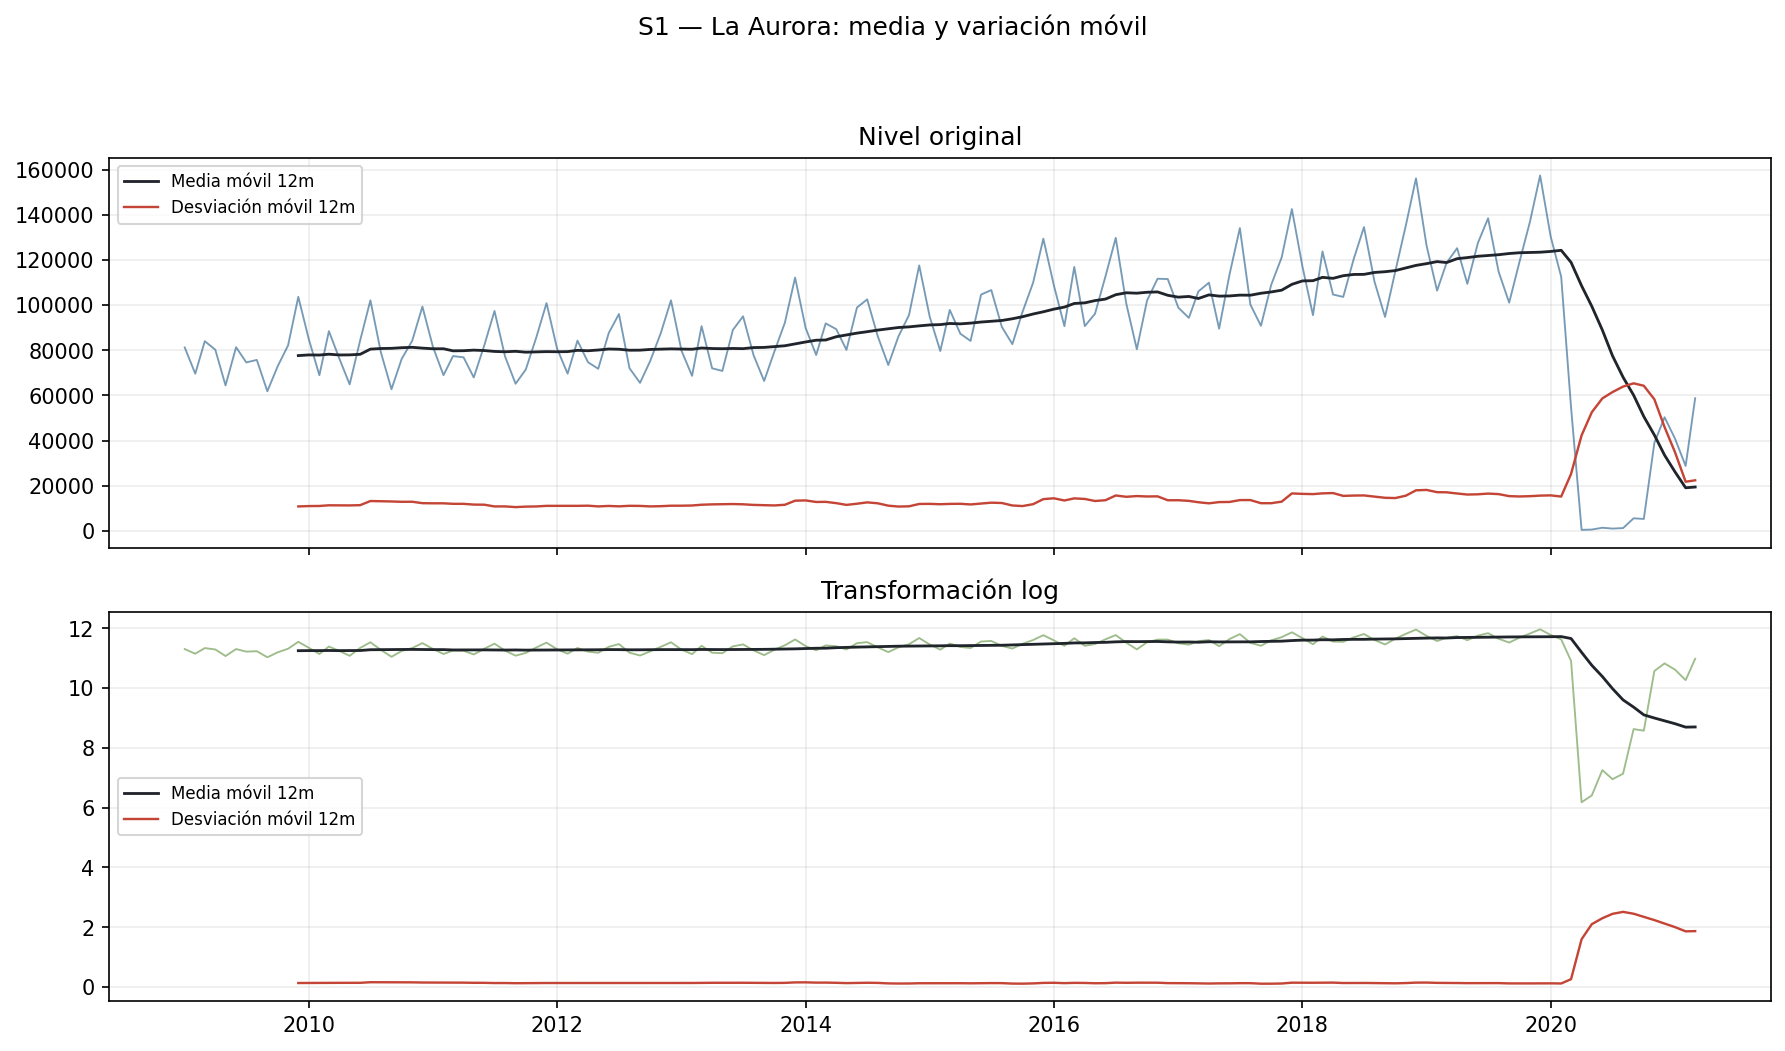

In [4]:
display(Image(filename=str(DIR_IMG / "s1_varianza.png")))

### Una diferencia regular basta; la estacional no aporta por sí sola

En logaritmo sin diferenciar, ADF no rechaza la raíz unitaria (`p=0.273`).
Con `d=1`, ADF y KPSS coinciden en estacionariedad (`p_ADF=0.027`,
`p_KPSS≈0.10`). La diferencia estacional aislada (`D=1` sin `d=1`) resulta NO
estacionaria, por lo que se evalúa únicamente en combinación con `d=1` dentro
de los candidatos SARIMA, sin asumirla como obligatoria.

,transformacion,p_ADF,p_KPSS,veredicto
0,Nivel,0.1505,0.100,"resultado mixto: KPSS dice estacionaria, ADF no"
1,log,0.2726,0.100,"resultado mixto: KPSS dice estacionaria, ADF no"
2,log + d=1,0.0269,0.100,estacionaria (ambas pruebas coinciden)
3,log + D=1,0.8311,0.044,NO estacionaria (ambas pruebas coinciden)
4,log + d=1 + D=1,0.0000,0.100,estacionaria (ambas pruebas coinciden)


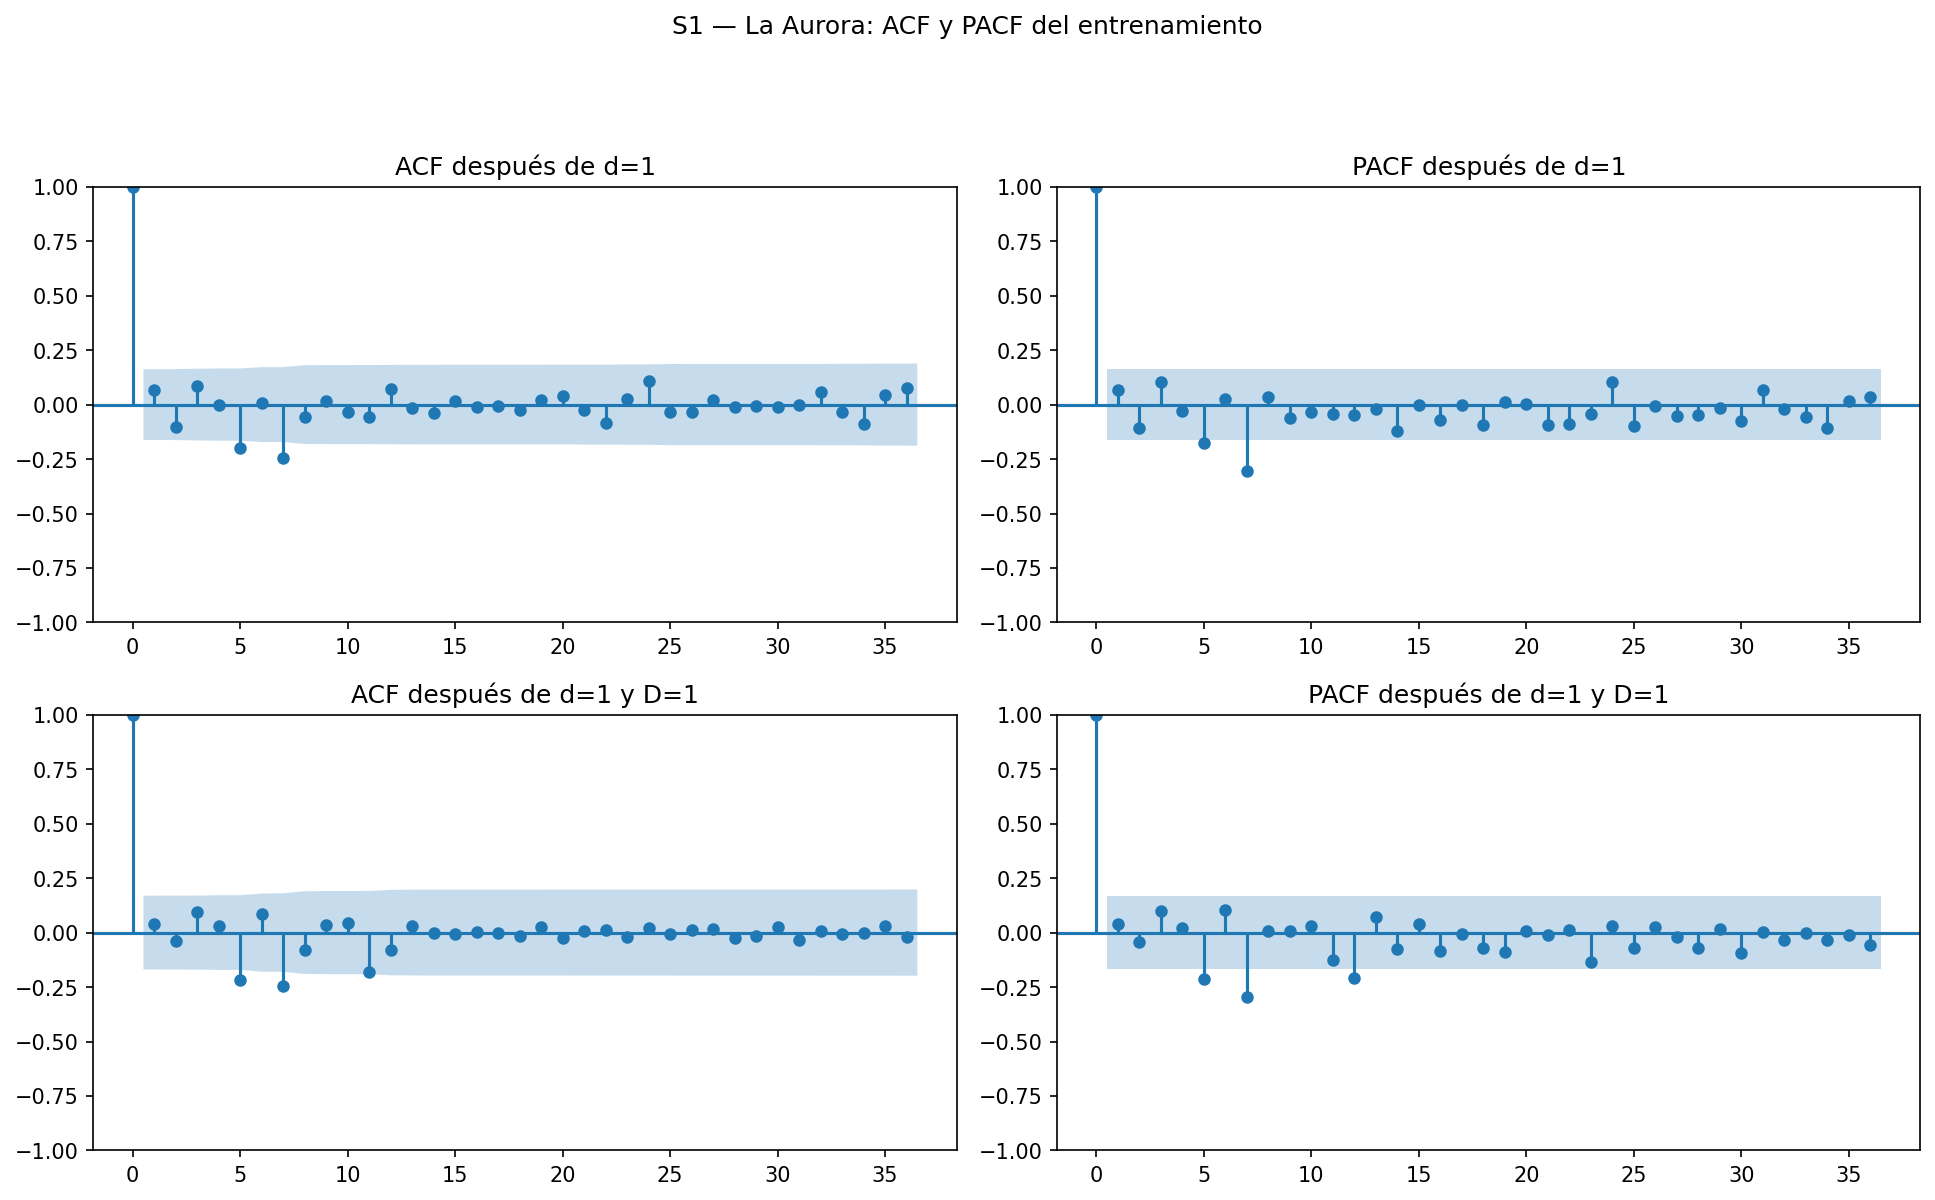

In [5]:
display(
    estacionariedad.loc[
        estacionariedad["serie"] == "S1_la_aurora",
        ["transformacion", "p_ADF", "p_KPSS", "veredicto"],
    ].round(4)
)
display(Image(filename=str(DIR_IMG / "s1_acf_pacf.png")))

### ARIMA(1,1,1) es el menos impreciso de los candidatos

ARIMA(1,1,1) obtiene MAE de 33,051 y RMSE de 38,251
viajeros, con MAPE de 33.1%, el menor entre las tres series de
este conjunto de series. Prophet queda detrás (RMSE 50,963) y Holt-Winters cerca de
Prophet (RMSE 42,889). `auto_arima` sugirió (1,0,1)(1,0,1,12), un orden sin
diferenciar que también se evaluó como candidato adicional.

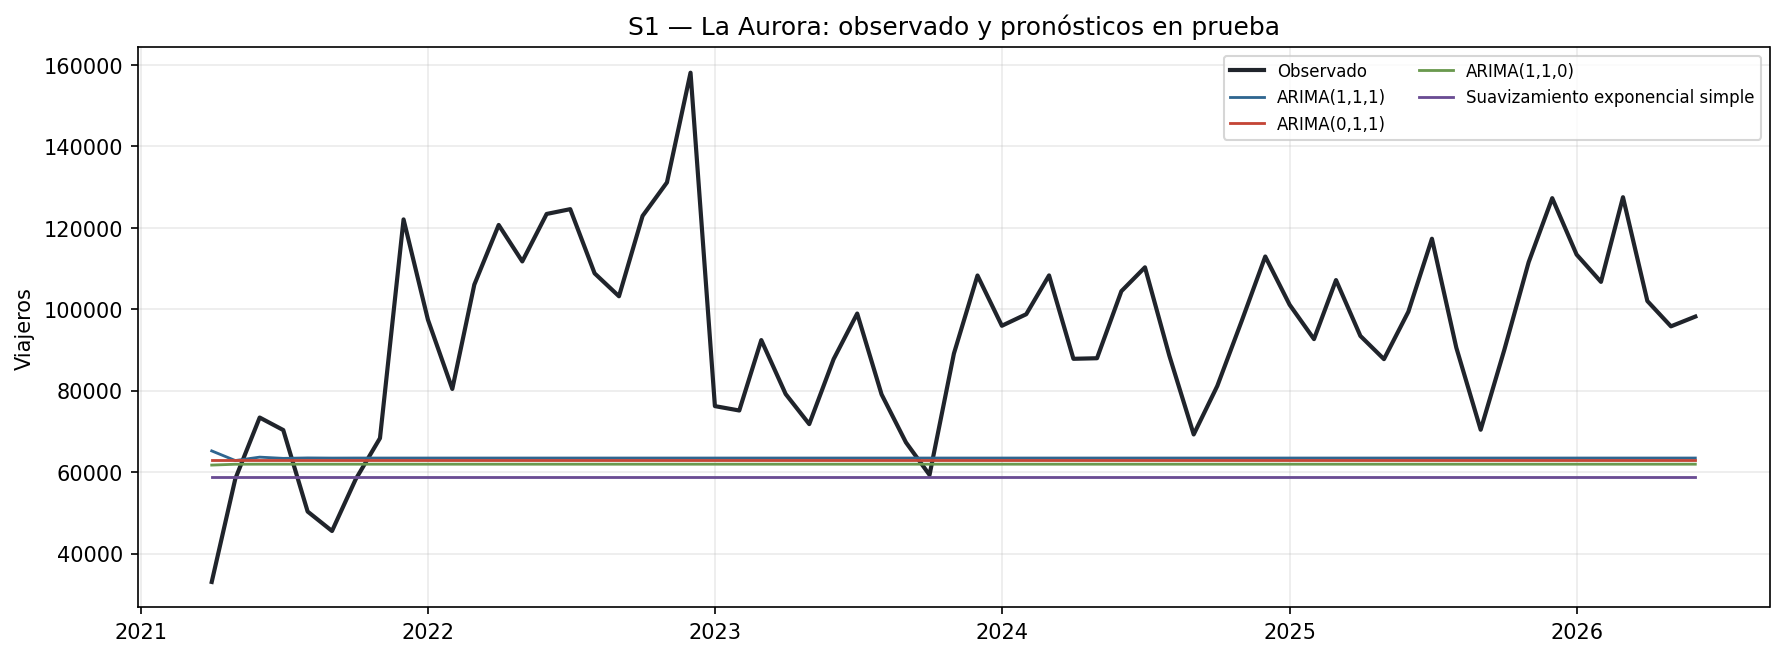

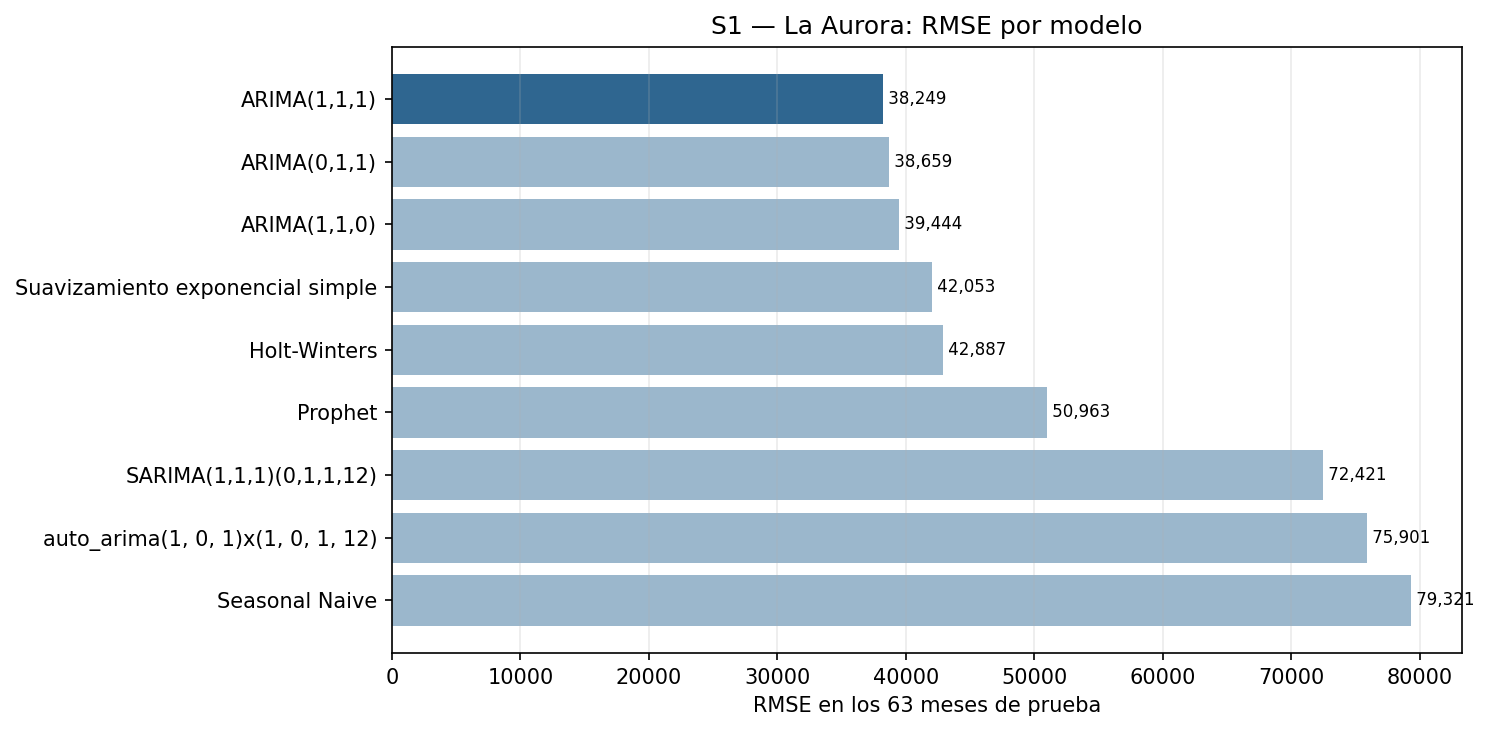

,serie,modelo,parametros,transformacion,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
0,S1_la_aurora,"ARIMA(1,1,1)","{'orden': (1, 1, 1), 'orden_estacional': (0, 0...",log,207.03,215.94,33049.42,38249.07,33.08,0.0745,0.000000e+00,True
1,S1_la_aurora,"ARIMA(0,1,1)","{'orden': (0, 1, 1), 'orden_estacional': (0, 0...",log,206.07,212.01,33467.50,38659.13,33.42,0.0613,0.000000e+00,False
2,S1_la_aurora,"ARIMA(1,1,0)","{'orden': (1, 1, 0), 'orden_estacional': (0, 0...",log,206.85,212.80,34250.39,39443.90,34.14,0.0606,0.000000e+00,False
3,S1_la_aurora,Suavizamiento exponencial simple,"{'tendencia': None, 'estacionalidad': None}",ninguna,NaN,NaN,36821.79,42053.32,36.56,0.0000,7.299584e-02,False
4,S1_la_aurora,Holt-Winters,"{'tendencia': 'aditiva amortiguada', 'estacion...",ninguna,NaN,NaN,38903.91,42886.69,39.49,0.2645,0.000000e+00,False
5,S1_la_aurora,Prophet,"{'crecimiento': 'linear', 'estacionalidad_anua...",ninguna,NaN,NaN,45973.06,50962.93,47.47,0.0000,8.507891e-22,False
6,S1_la_aurora,"SARIMA(1,1,1)(0,1,1,12)","{'orden': (1, 1, 1), 'orden_estacional': (0, 1...",log,187.11,198.26,68210.16,72421.31,71.99,0.0302,0.000000e+00,False
7,S1_la_aurora,"auto_arima(1, 0, 1)x(1, 0, 1, 12)","{'orden': (1, 0, 1), 'orden_estacional': (1, 0...",log,189.57,204.03,71902.88,75900.74,76.29,0.0317,0.000000e+00,False
8,S1_la_aurora,Seasonal Naive,{'rezago': 12},ninguna,NaN,NaN,75518.44,79320.76,81.48,0.0000,2.170202e-94,False


In [6]:
display(Image(filename=str(DIR_IMG / "s1_pronosticos.png")))
display(Image(filename=str(DIR_IMG / "s1_rmse_modelos.png")))
display(
    metricas.loc[metricas["serie"] == "S1_la_aurora"].round({
        "AIC": 2, "BIC": 2, "MAE": 2, "RMSE": 2,
        "MAPE": 2, "Ljung_Box_p": 4,
    })
)

### Un AIC competitivo no impidió un pronóstico explosivo

SARIMA(2,1,1)(1,1,0,12) obtuvo el AIC más bajo entre los candidatos
ARIMA/SARIMA de S1, pero al invertir la transformación logarítmica sobre 63
pasos su pronóstico se dispara a un orden de magnitud sin sentido económico
(RMSE mayor a 10¹³). Se conserva en la tabla de métricas como evidencia de
por qué fue descartado y se omite de la escala visual del gráfico de barras,
igual que ocurrió con un candidato inestable de S5. ARIMA(1,1,1)
obtiene `p=0.074` en Ljung-Box; al 5% no se rechaza la ausencia de
autocorrelación, aunque el margen es estrecho.

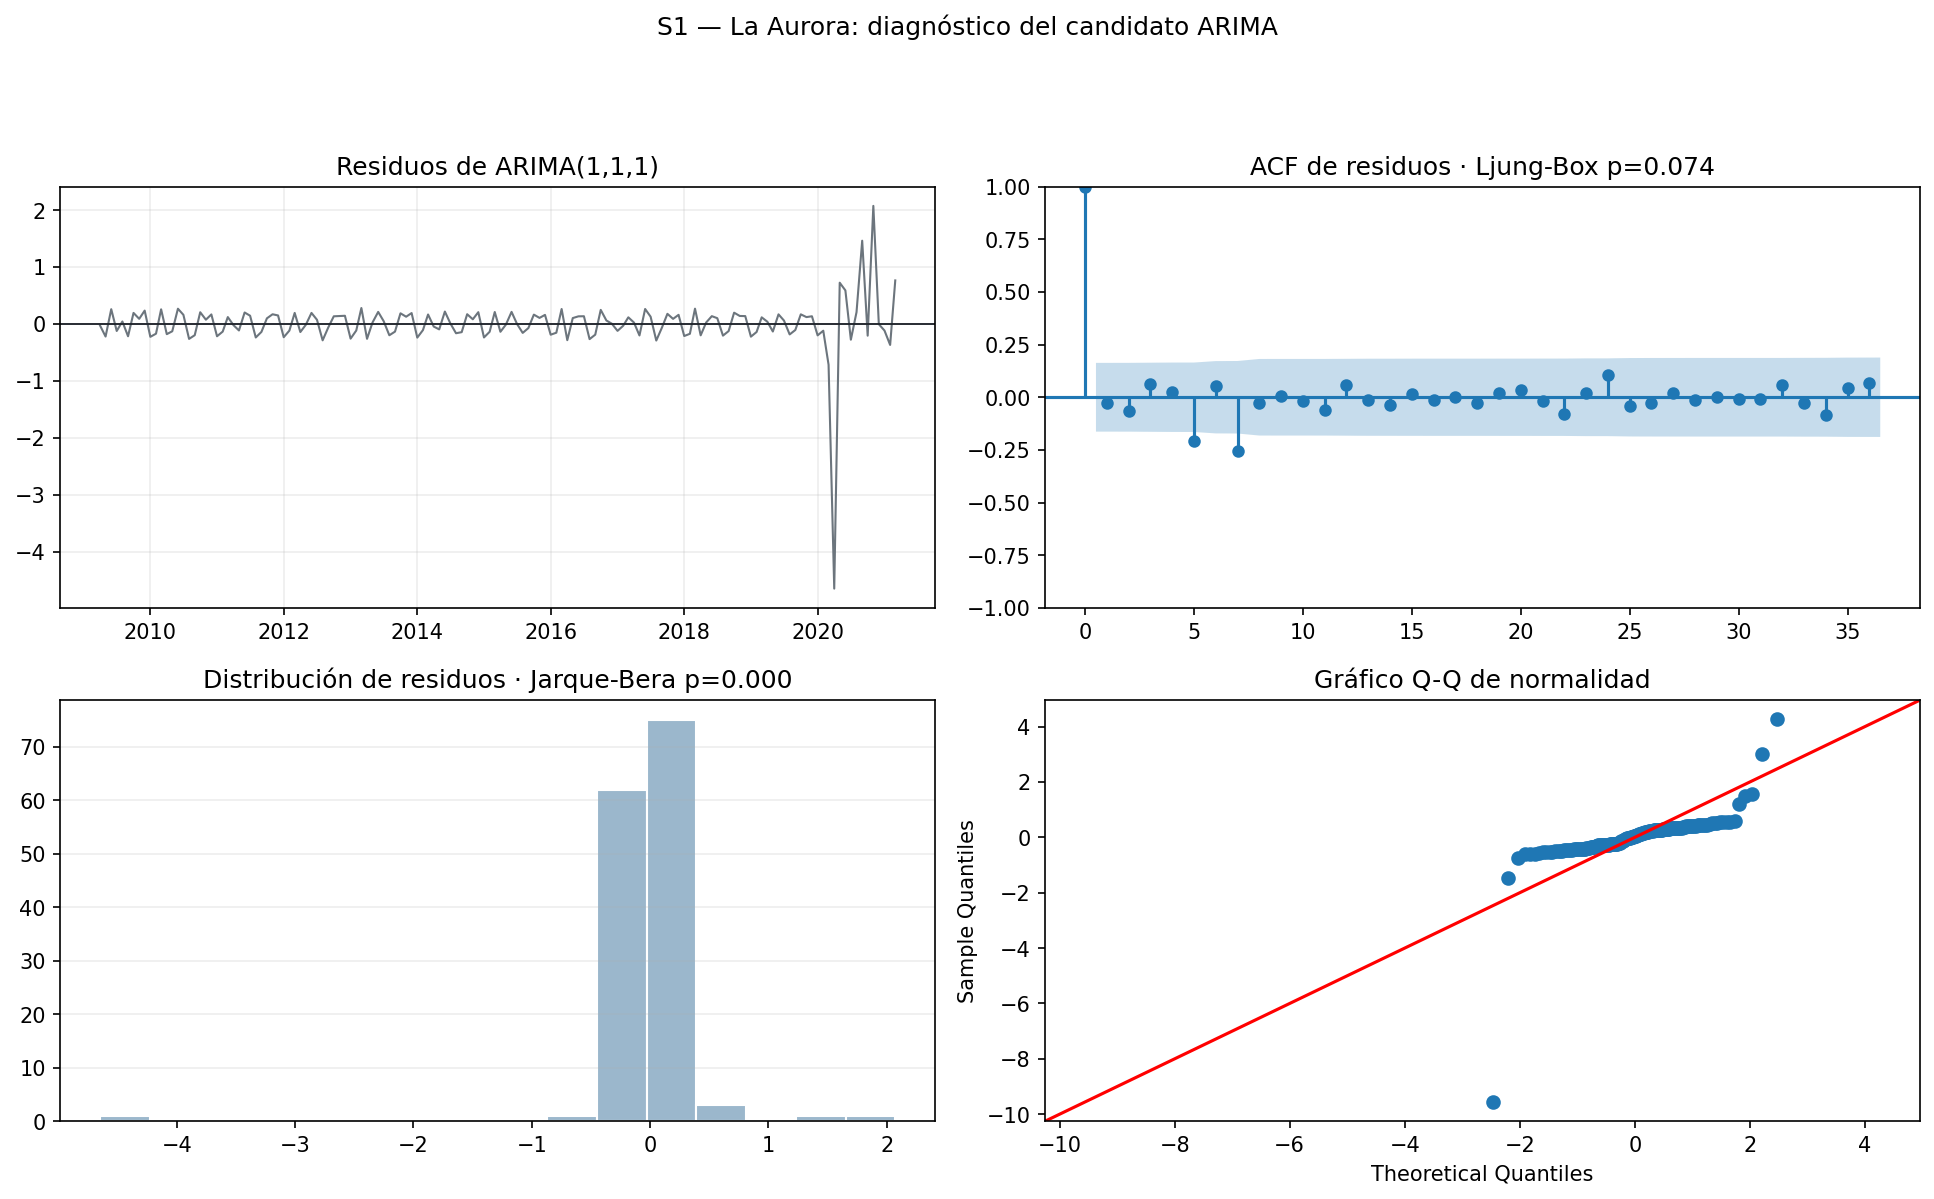

In [7]:
display(Image(filename=str(DIR_IMG / "s1_residuos.png")))

## S2 — Valle Nuevo

S2 no contaba con exploración, descomposición ni estacionariedad en el
avance; este notebook lo completa de principio a fin. Contiene 210 meses,
desde enero de 2009 hasta junio de 2026, con un mínimo de 80 viajeros en
entrenamiento y sin meses en cero. Valle Nuevo es la principal frontera
terrestre hacia El Salvador.

### La serie completa muestra el mismo quiebre pandémico que el resto

La franja amarilla marca la pandemia y la línea roja el inicio de la prueba.
Valle Nuevo cae a niveles mínimos en 2020 y, al igual que las fronteras
aéreas, todavía estaba recuperándose cuando terminó el entrenamiento.

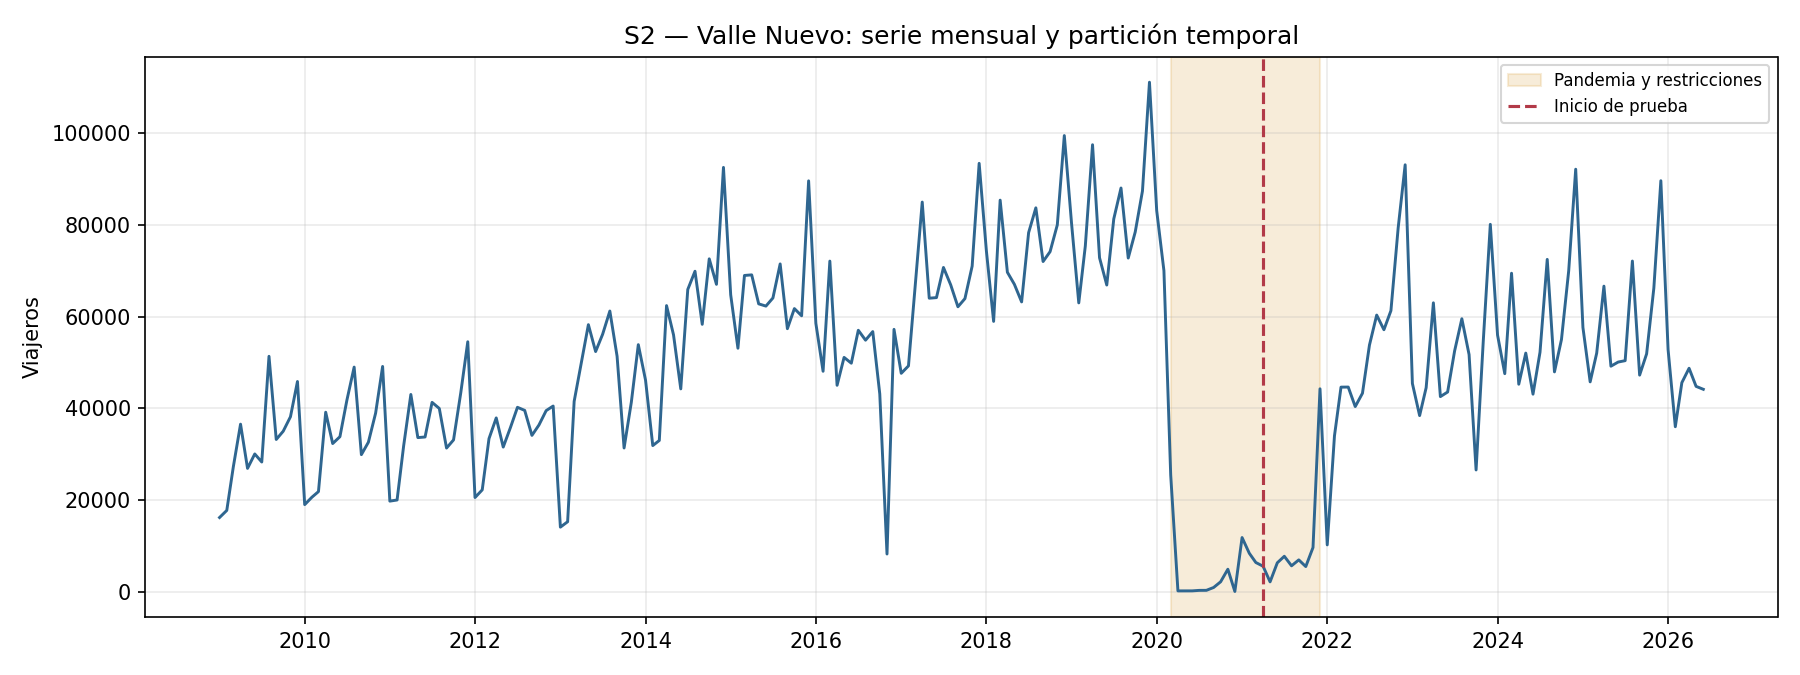

In [8]:
display(Image(filename=str(DIR_IMG / "s2_serie_particion.png")))

### La tendencia es el componente dominante

La fuerza de tendencia es 0.766, frente a una fuerza estacional
de 0.311. A diferencia de La Aurora, el tráfico terrestre de
Valle Nuevo muestra un patrón mensual más plano y un crecimiento de fondo más
marcado antes de 2020.

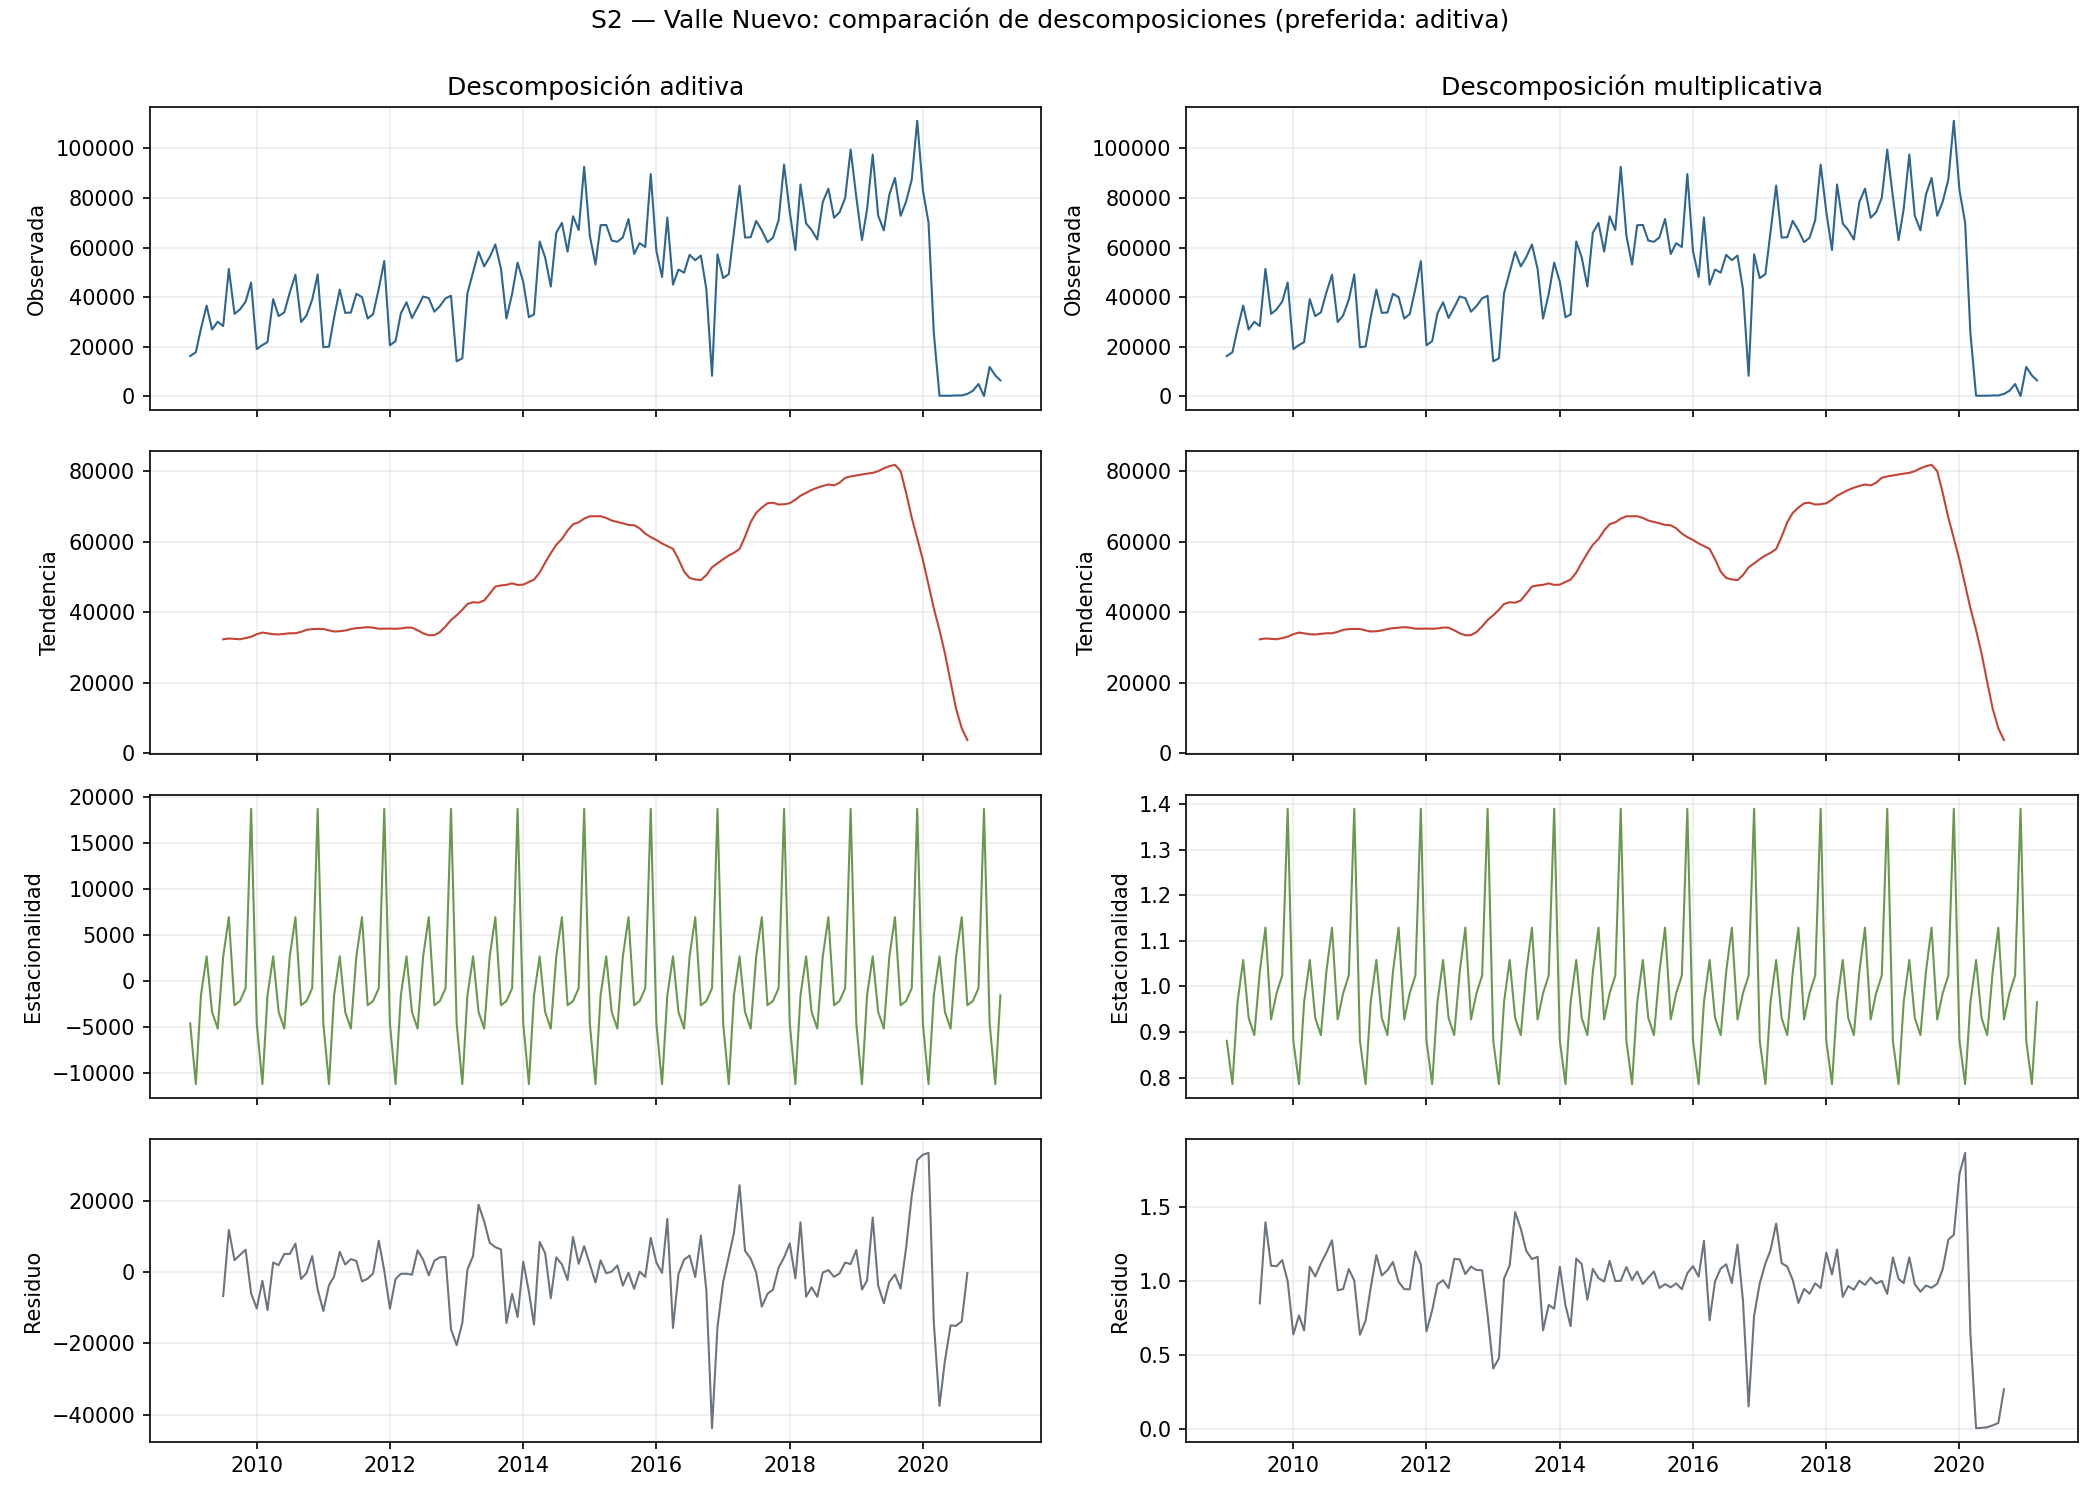

In [9]:
display(Image(filename=str(DIR_IMG / "s2_descomposicion.png")))

### El logaritmo es válido porque S2 tampoco tiene ceros

El mínimo de entrenamiento es 80 viajeros, siempre positivo, por lo que se
aplica logaritmo completo. La transformación reduce la influencia de los
picos y estabiliza la variación para comparar años distintos.

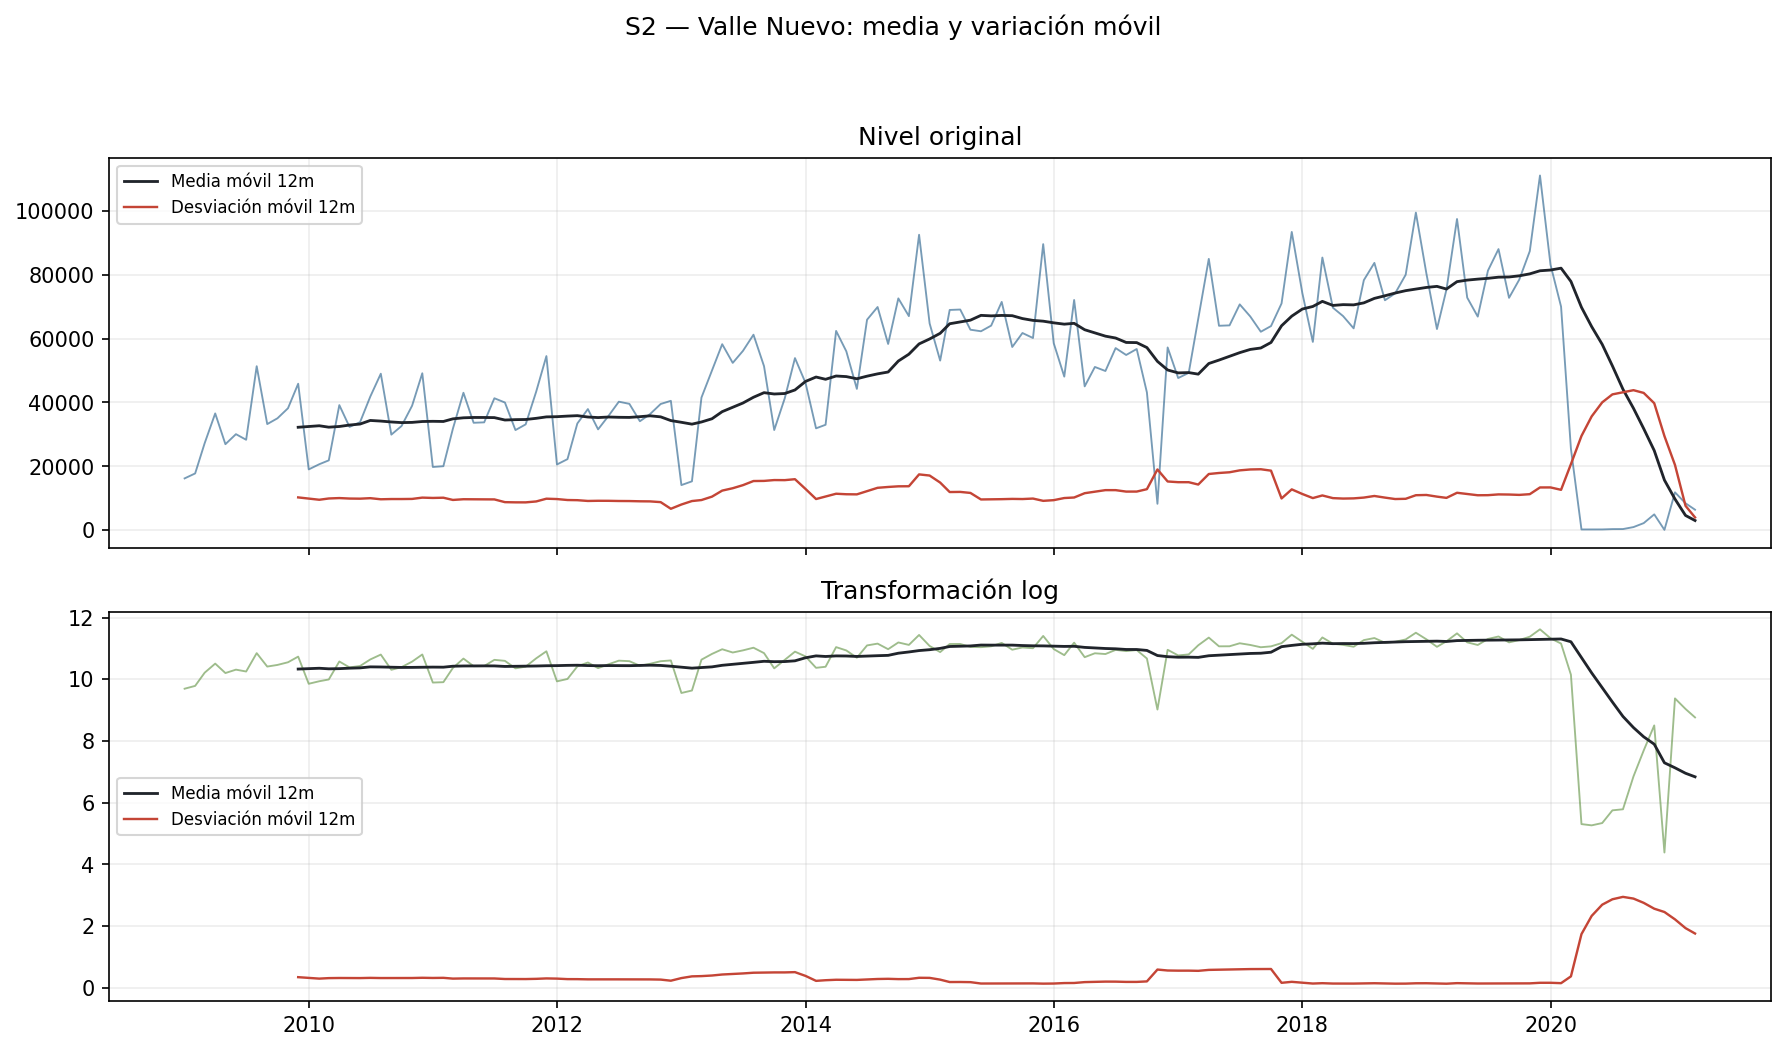

In [10]:
display(Image(filename=str(DIR_IMG / "s2_varianza.png")))

### Una diferencia regular estabiliza la media

En logaritmo sin diferenciar, ADF no rechaza la raíz unitaria (`p=0.195`).
Con `d=1`, ADF y KPSS coinciden en estacionariedad (`p_ADF<0.001`,
`p_KPSS≈0.10`). Igual que en S1, la diferencia estacional aislada no es
estacionaria por sí sola (`p_ADF=0.783`), así que se prueba solo combinada con
`d=1` dentro de los candidatos SARIMA.

,transformacion,p_ADF,p_KPSS,veredicto
5,Nivel,0.3648,0.0636,"resultado mixto: KPSS dice estacionaria, ADF no"
6,log,0.1952,0.1000,"resultado mixto: KPSS dice estacionaria, ADF no"
7,log + d=1,0.0000,0.1000,estacionaria (ambas pruebas coinciden)
8,log + D=1,0.7827,0.0256,NO estacionaria (ambas pruebas coinciden)
9,log + d=1 + D=1,0.0000,0.1000,estacionaria (ambas pruebas coinciden)


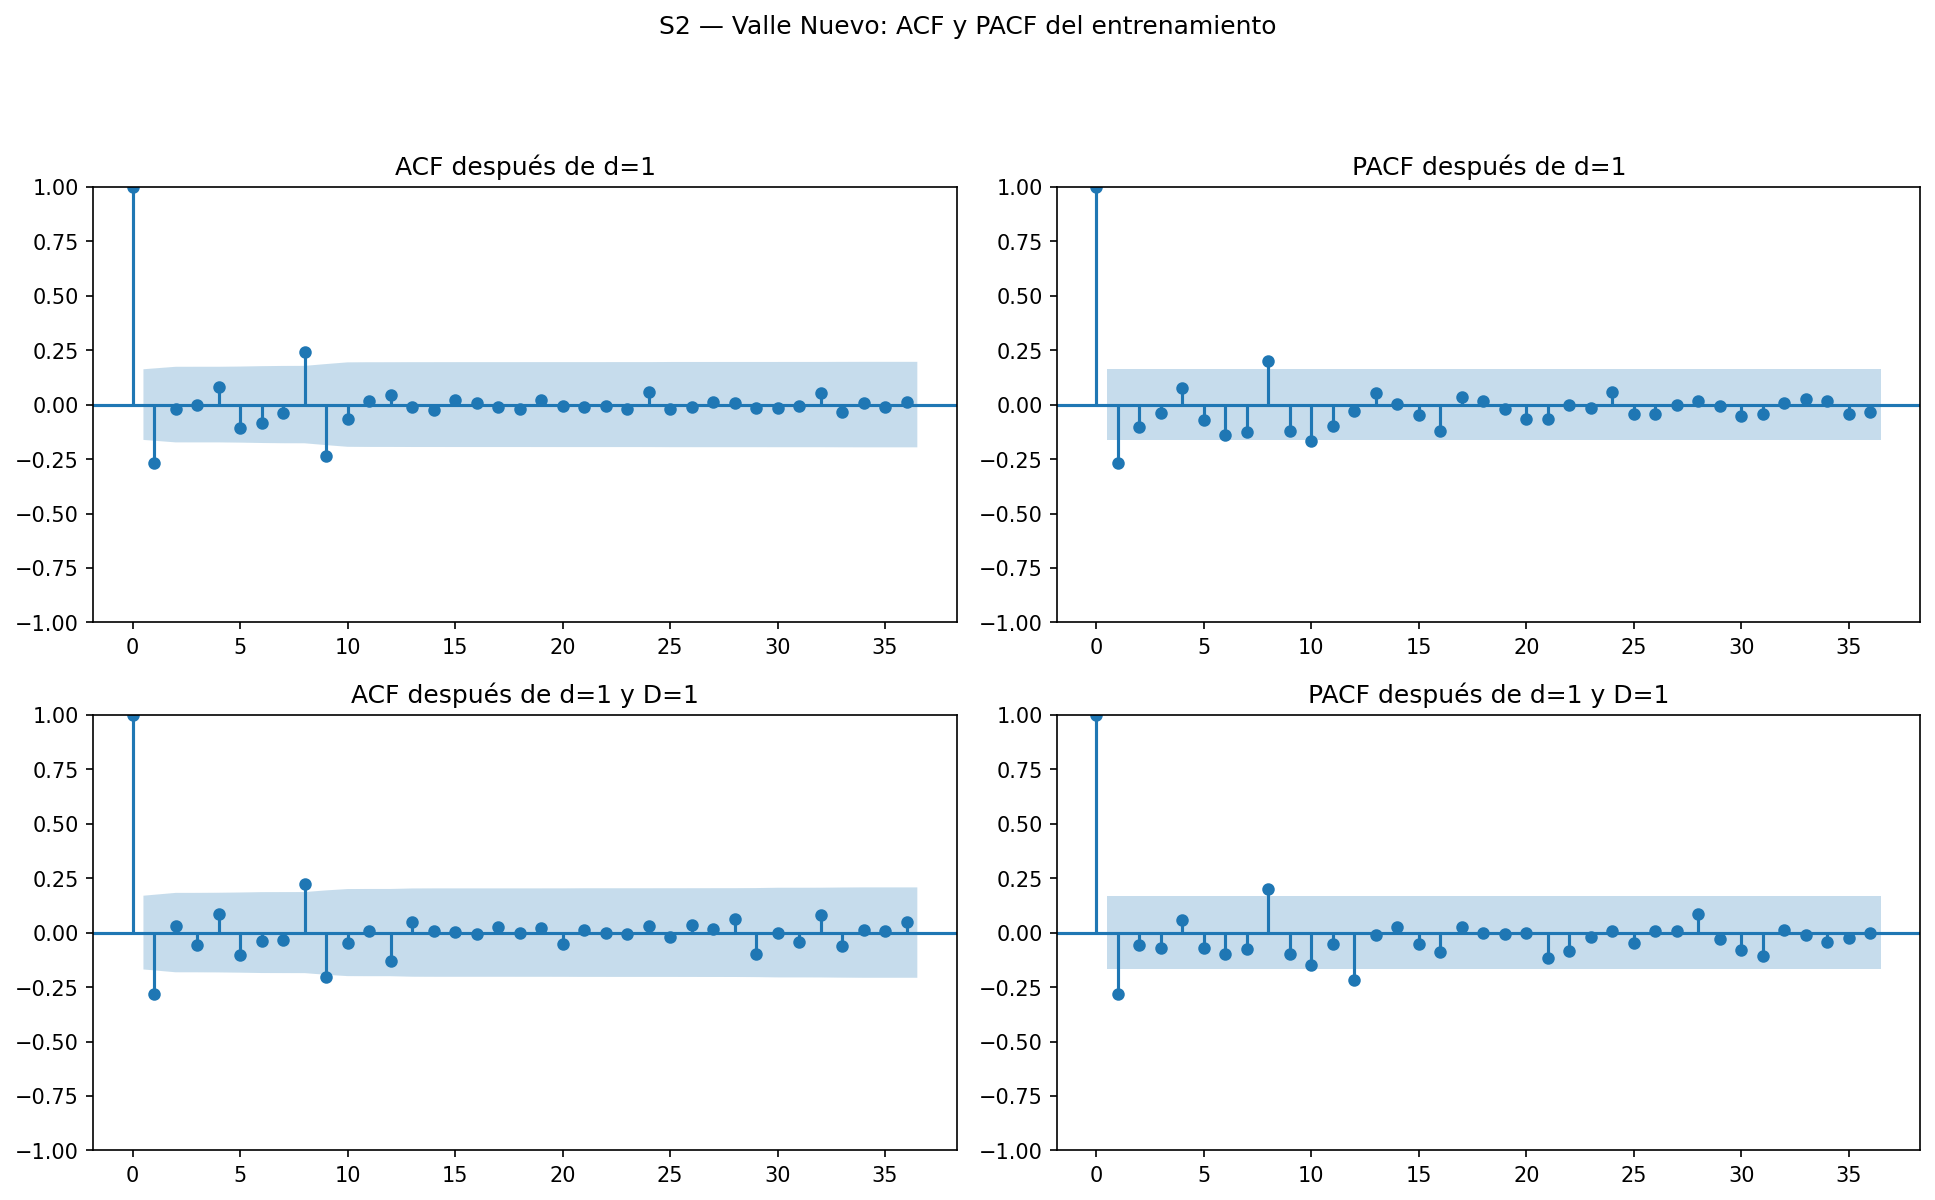

In [11]:
display(
    estacionariedad.loc[
        estacionariedad["serie"] == "S2_valle_nuevo",
        ["transformacion", "p_ADF", "p_KPSS", "veredicto"],
    ].round(4)
)
display(Image(filename=str(DIR_IMG / "s2_acf_pacf.png")))

### Prophet obtiene el menor error, con un MAPE que exige cautela

Prophet obtiene MAE de 16,804 y RMSE de 23,187 viajeros,
muy por debajo del resto de candidatos: el siguiente mejor, Holt-Winters,
tiene RMSE de 38,126. Sin embargo, el MAPE de Prophet es
157.6%, superior a 100% porque algunos meses de prueba
tienen valores observados pequeños frente al error absoluto. Por eso el MAPE
se reporta como referencia adicional y la selección del mejor modelo se basa
en RMSE, no en MAPE.

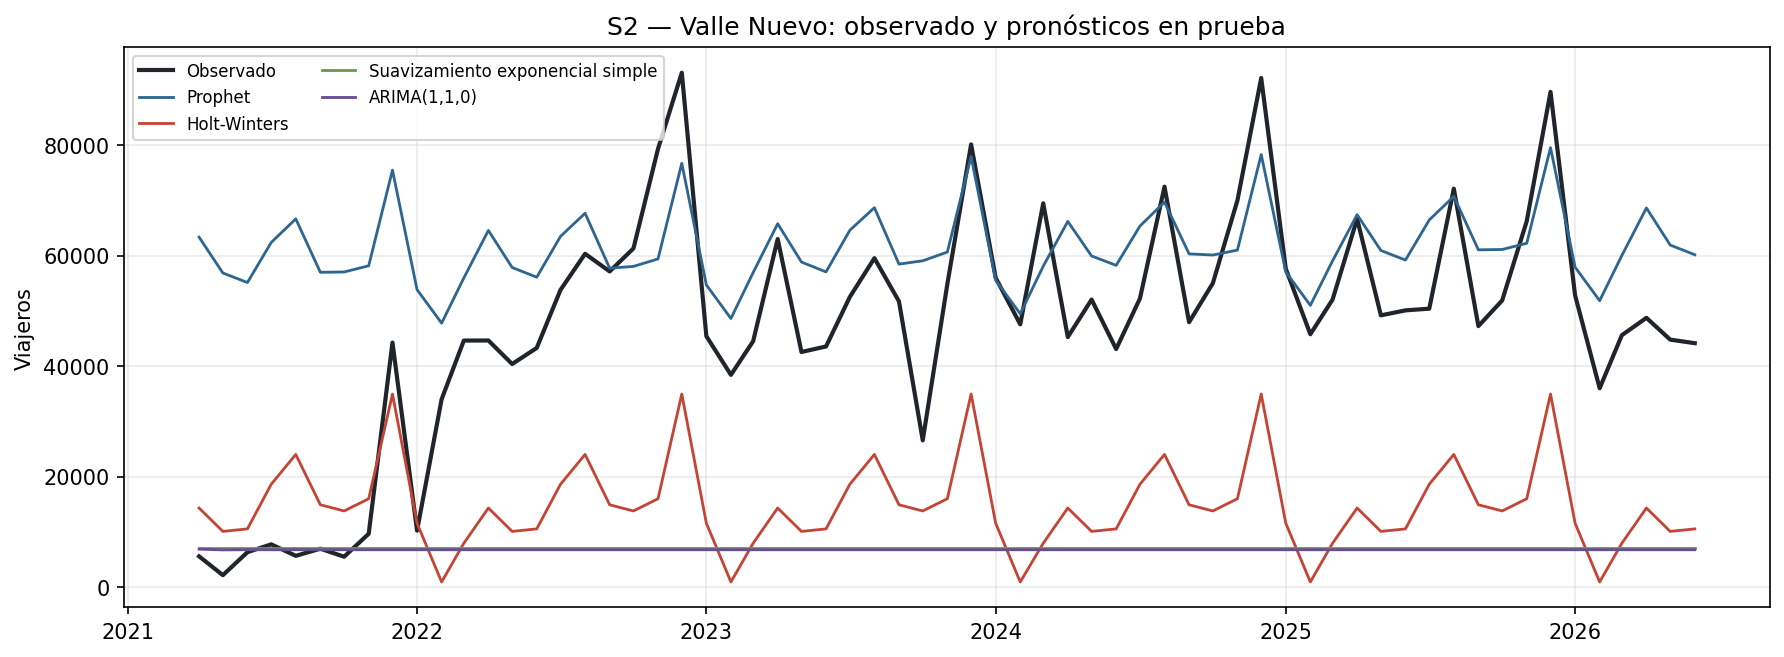

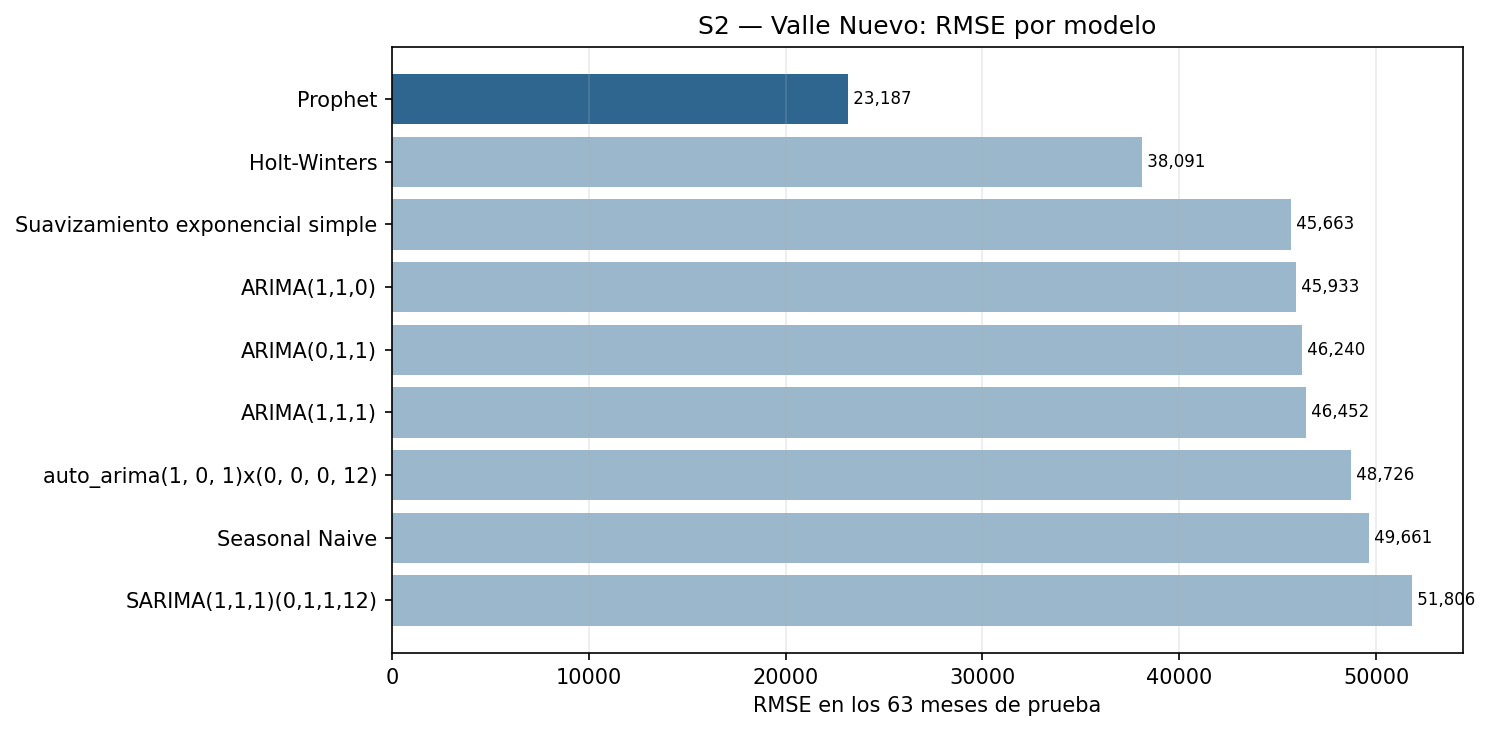

,serie,modelo,parametros,transformacion,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
9,S2_valle_nuevo,Prophet,"{'crecimiento': 'linear', 'estacionalidad_anua...",ninguna,NaN,NaN,16803.85,23186.82,157.64,0.0000,2.621553e-12,True
10,S2_valle_nuevo,Holt-Winters,"{'tendencia': 'aditiva amortiguada', 'estacion...",ninguna,NaN,NaN,35209.78,38091.01,85.43,0.8812,2.314697e-56,False
11,S2_valle_nuevo,Suavizamiento exponencial simple,"{'tendencia': None, 'estacionalidad': None}",ninguna,NaN,NaN,40769.92,45662.78,79.97,0.0000,2.893296e-04,False
12,S2_valle_nuevo,"ARIMA(1,1,0)","{'orden': (1, 1, 0), 'orden_estacional': (0, 0...",log,330.74,336.69,41024.48,45933.38,80.11,0.0139,0.000000e+00,False
13,S2_valle_nuevo,"ARIMA(0,1,1)","{'orden': (0, 1, 1), 'orden_estacional': (0, 0...",log,327.55,333.49,41313.69,46240.12,80.30,0.0496,0.000000e+00,False
14,S2_valle_nuevo,"ARIMA(1,1,1)","{'orden': (1, 1, 1), 'orden_estacional': (0, 0...",log,329.50,338.41,41518.97,46452.18,80.52,0.0552,0.000000e+00,False
15,S2_valle_nuevo,"auto_arima(1, 0, 1)x(0, 0, 0, 12)","{'orden': (1, 0, 1), 'orden_estacional': (0, 0...",log,330.98,339.91,43693.08,48726.17,84.83,0.0494,0.000000e+00,False
16,S2_valle_nuevo,Seasonal Naive,{'rezago': 12},ninguna,NaN,NaN,44707.23,49660.59,91.39,0.0000,1.203486e-32,False
17,S2_valle_nuevo,"SARIMA(1,1,1)(0,1,1,12)","{'orden': (1, 1, 1), 'orden_estacional': (0, 1...",log,303.09,314.24,47115.32,51805.58,96.96,0.1894,0.000000e+00,False


In [12]:
display(Image(filename=str(DIR_IMG / "s2_pronosticos.png")))
display(Image(filename=str(DIR_IMG / "s2_rmse_modelos.png")))
display(
    metricas.loc[metricas["serie"] == "S2_valle_nuevo"].round({
        "AIC": 2, "BIC": 2, "MAE": 2, "RMSE": 2,
        "MAPE": 2, "Ljung_Box_p": 4,
    })
)

### Los residuos de Prophet conservan autocorrelación

El diagnóstico resumido de Ljung-Box para Prophet da `p≈0.0000`: los
residuos todavía muestran estructura temporal sin explicar, a pesar de tener
el menor error en prueba. Entre los candidatos ARIMA/SARIMA, ARIMA(1,1,1)
tiene el residuo más cercano a ruido blanco (`p=0.055`, cerca del umbral de
5%), pero su RMSE (46,452) duplica al de Prophet. A diferencia de S1, en S2
ningún candidato ARIMA/SARIMA produjo un pronóstico inestable.

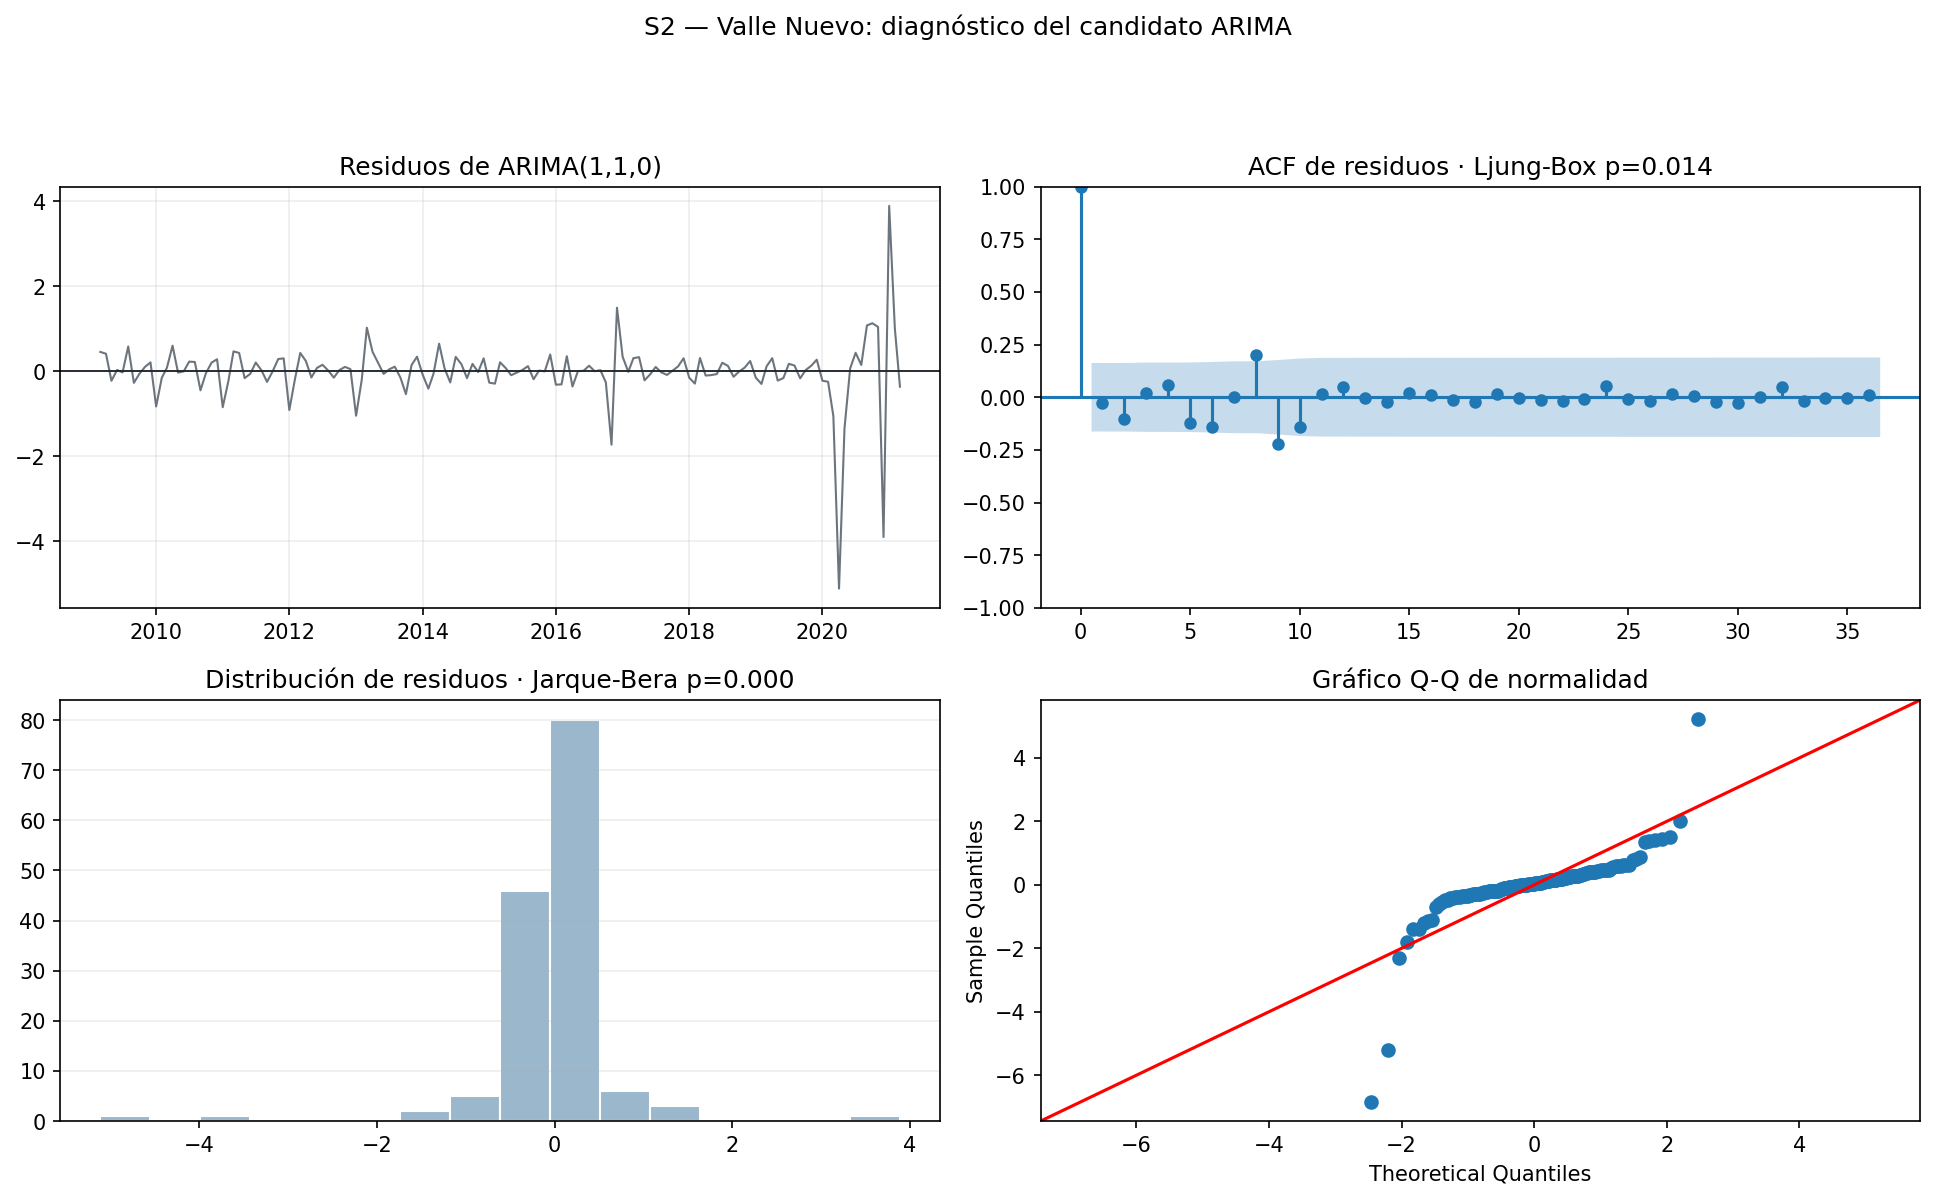

In [13]:
display(Image(filename=str(DIR_IMG / "s2_residuos.png")))

## S6 — Guatemala

S6 corresponde a viajeros con `País = Guatemala`. Contiene 210 meses, sin
ceros en entrenamiento, pero con 42 meses consecutivos en cero en prueba,
desde enero de 2023 hasta junio de 2026. Esos ceros no son una caída real:
Guatemala deja de aparecer como categoría individual de `País` después del
cambio de granularidad de los datos desde 2023. Además, esta serie representa
principalmente el retorno de residentes guatemaltecos al país y no debe
interpretarse como turismo extranjero, a diferencia de El Salvador o Estados
Unidos.

### La caída de 2023 en adelante es metodológica, no real

La franja amarilla marca la pandemia y la línea roja el inicio de la prueba.
El tramo plano en cero desde 2023 se distingue claramente del cierre
pandémico de 2020: el primero es un cambio de cómo se reporta la variable
`País`, y el segundo es una caída real de movilidad.

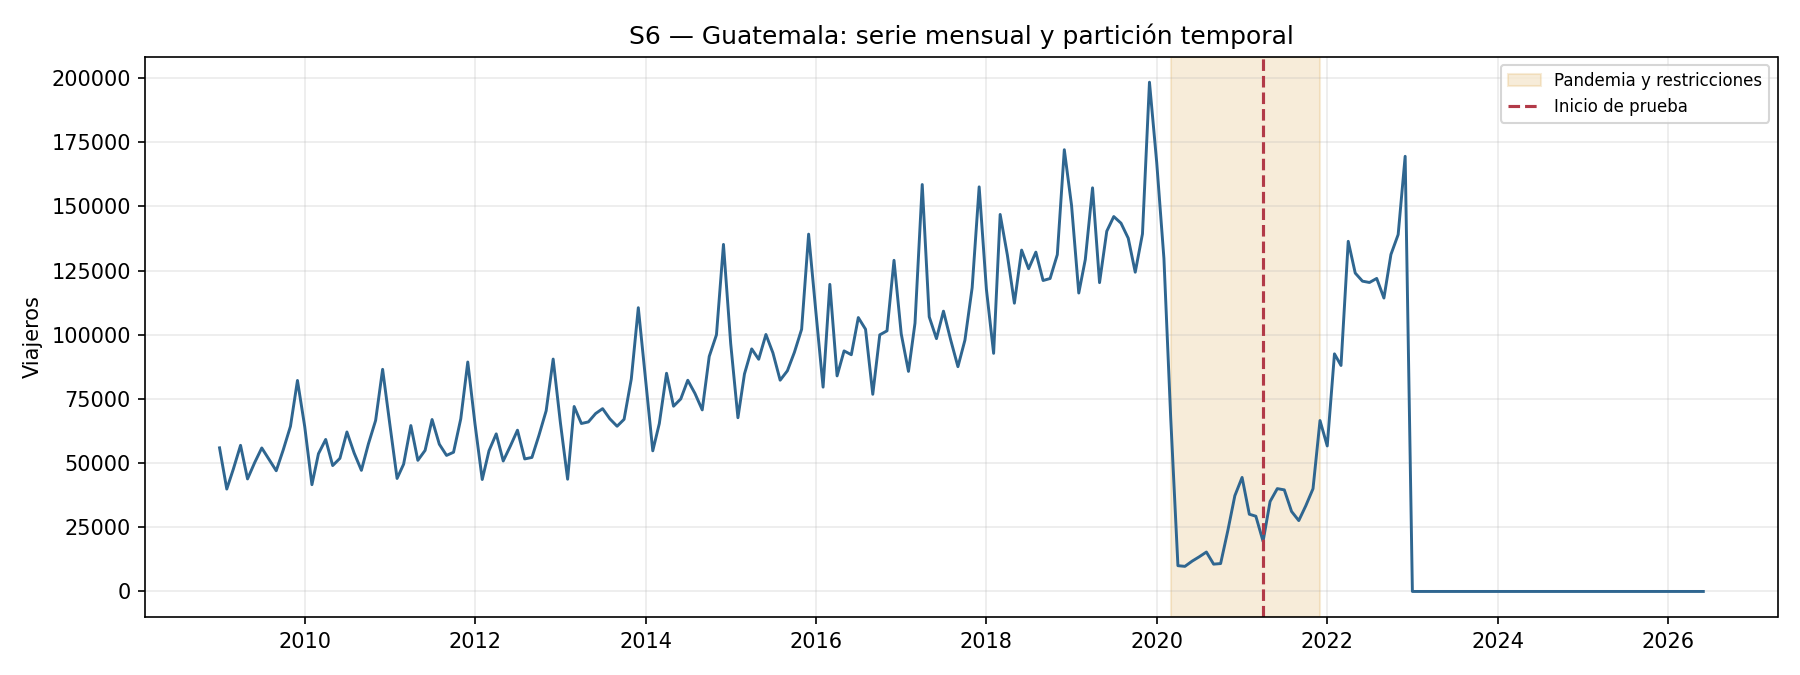

In [14]:
display(Image(filename=str(DIR_IMG / "s6_serie_particion.png")))

### Tendencia y estacionalidad conviven con el corte metodológico

La fuerza de tendencia estimada sobre el entrenamiento es 0.840
y la fuerza estacional es 0.506. Estas cifras describen únicamente
el tramo de entrenamiento (2009-2021), que no incluye los ceros de 2023 en
adelante, porque el cambio de granularidad ocurre después del corte oficial
70/30.

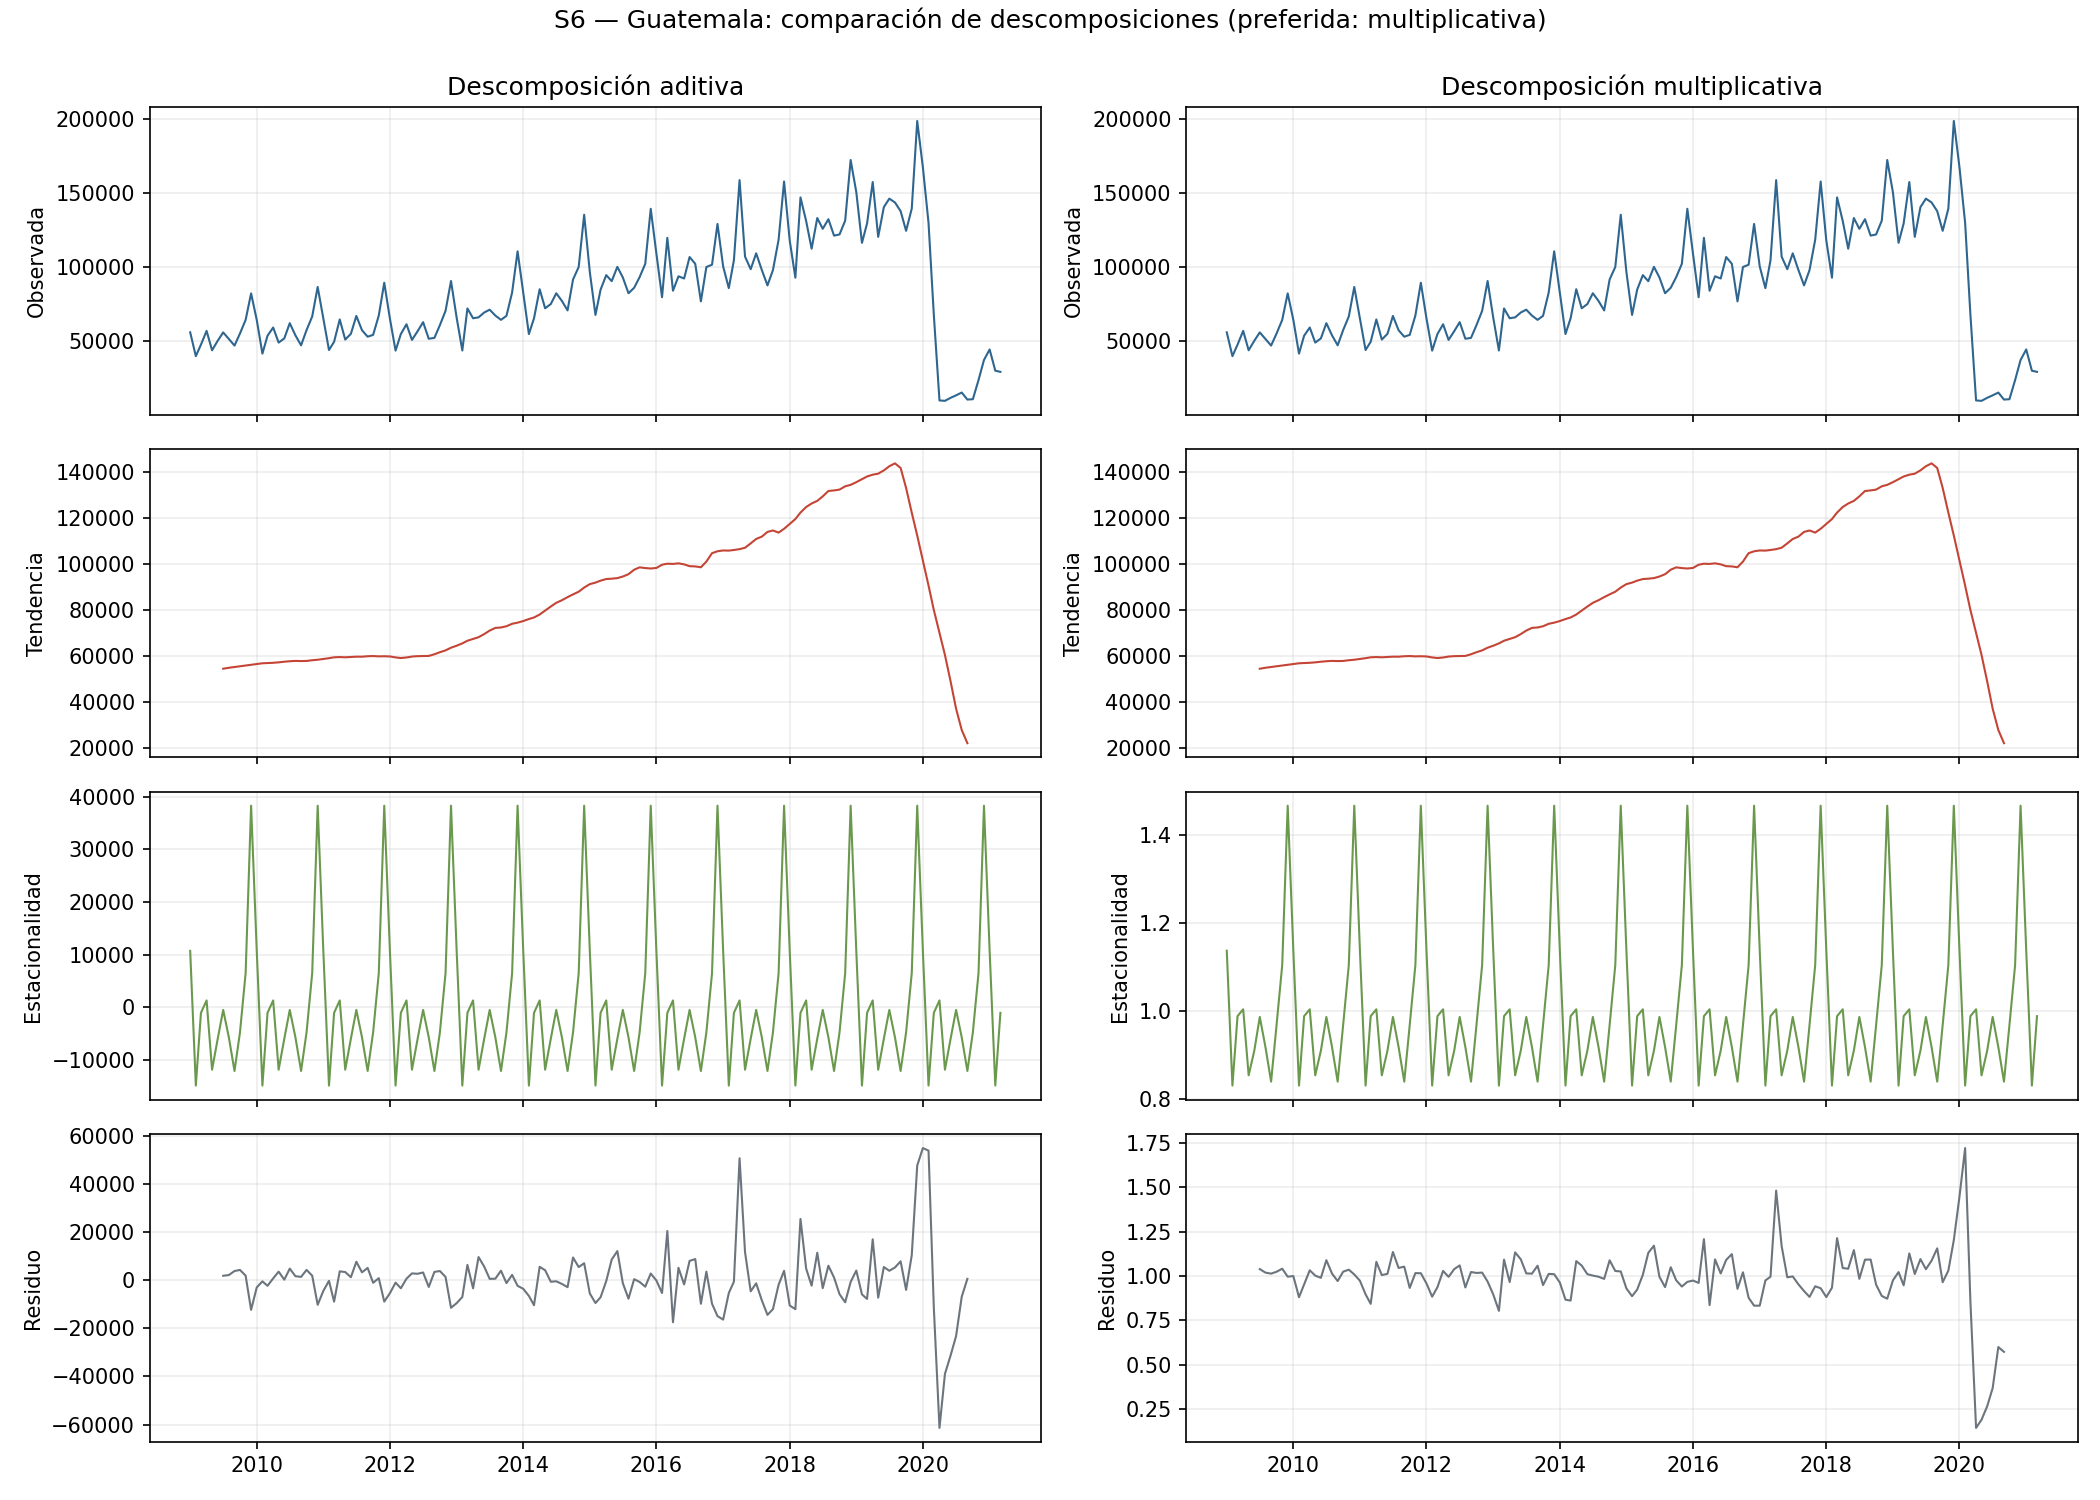

In [15]:
display(Image(filename=str(DIR_IMG / "s6_descomposicion.png")))

### `log1p` se usa por compatibilidad futura con ceros, no porque el entrenamiento los tenga

El entrenamiento de S6 no contiene ceros (mínimo 9,779 viajeros), pero se usa
`log1p` en vez de logaritmo completo porque la serie sí tiene ceros en el
período de prueba y la transformación debe ser la misma para ajustar y para
invertir el pronóstico. Usar logaritmo común habría funcionado en
entrenamiento, pero un futuro reajuste con datos más recientes fallaría en
cuanto se agregara un mes en cero.

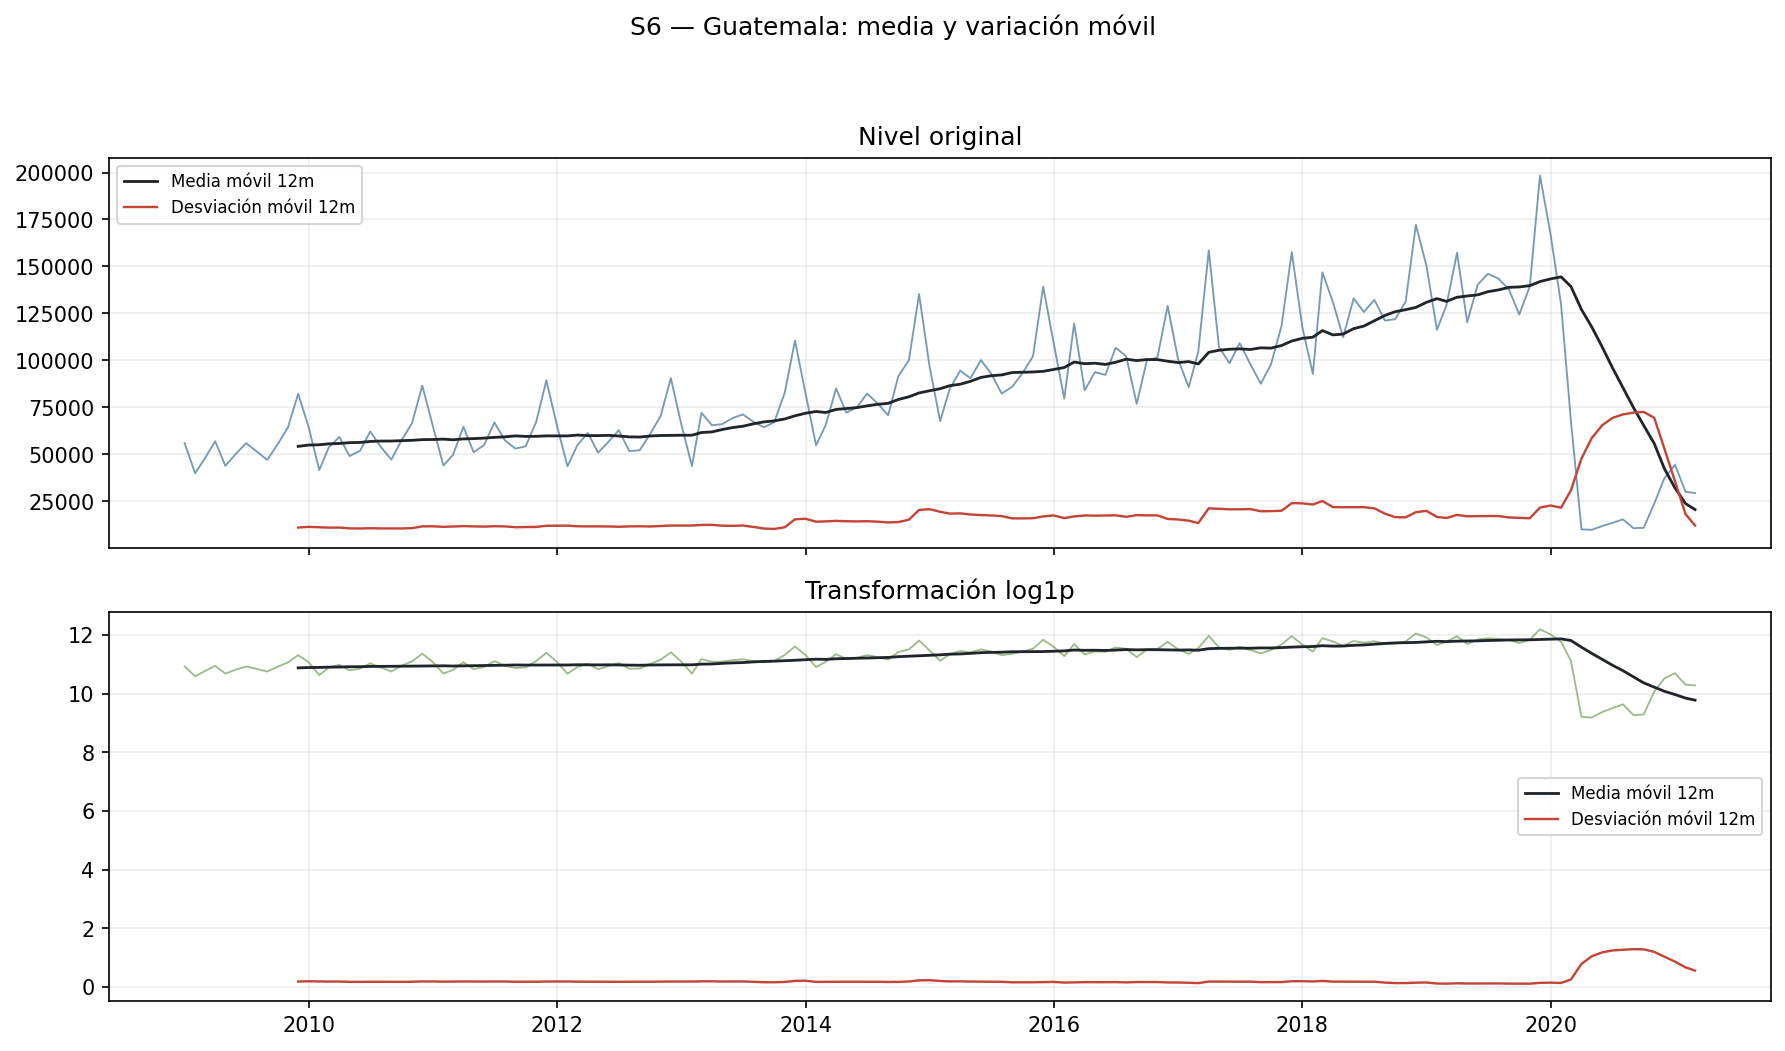

In [16]:
display(Image(filename=str(DIR_IMG / "s6_varianza.png")))

### La diferencia regular vuelve a ser suficiente

En `log1p` sin diferenciar, el resultado es mixto (`p_ADF=0.383`,
`p_KPSS≈0.10`). Con `d=1`, ADF y KPSS coinciden en estacionariedad
(`p_ADF=0.035`). La diferencia estacional aislada no es estacionaria
(`p_ADF=0.873`), por lo que, igual que en S1 y S2, se prueba solo combinada
con `d=1` en los candidatos SARIMA.

,transformacion,p_ADF,p_KPSS,veredicto
10,Nivel,0.2136,0.0213,NO estacionaria (ambas pruebas coinciden)
11,log1p,0.3834,0.1000,"resultado mixto: KPSS dice estacionaria, ADF no"
12,log1p + d=1,0.0345,0.1000,estacionaria (ambas pruebas coinciden)
13,log1p + D=1,0.8729,0.0281,NO estacionaria (ambas pruebas coinciden)
14,log1p + d=1 + D=1,0.0031,0.1000,estacionaria (ambas pruebas coinciden)


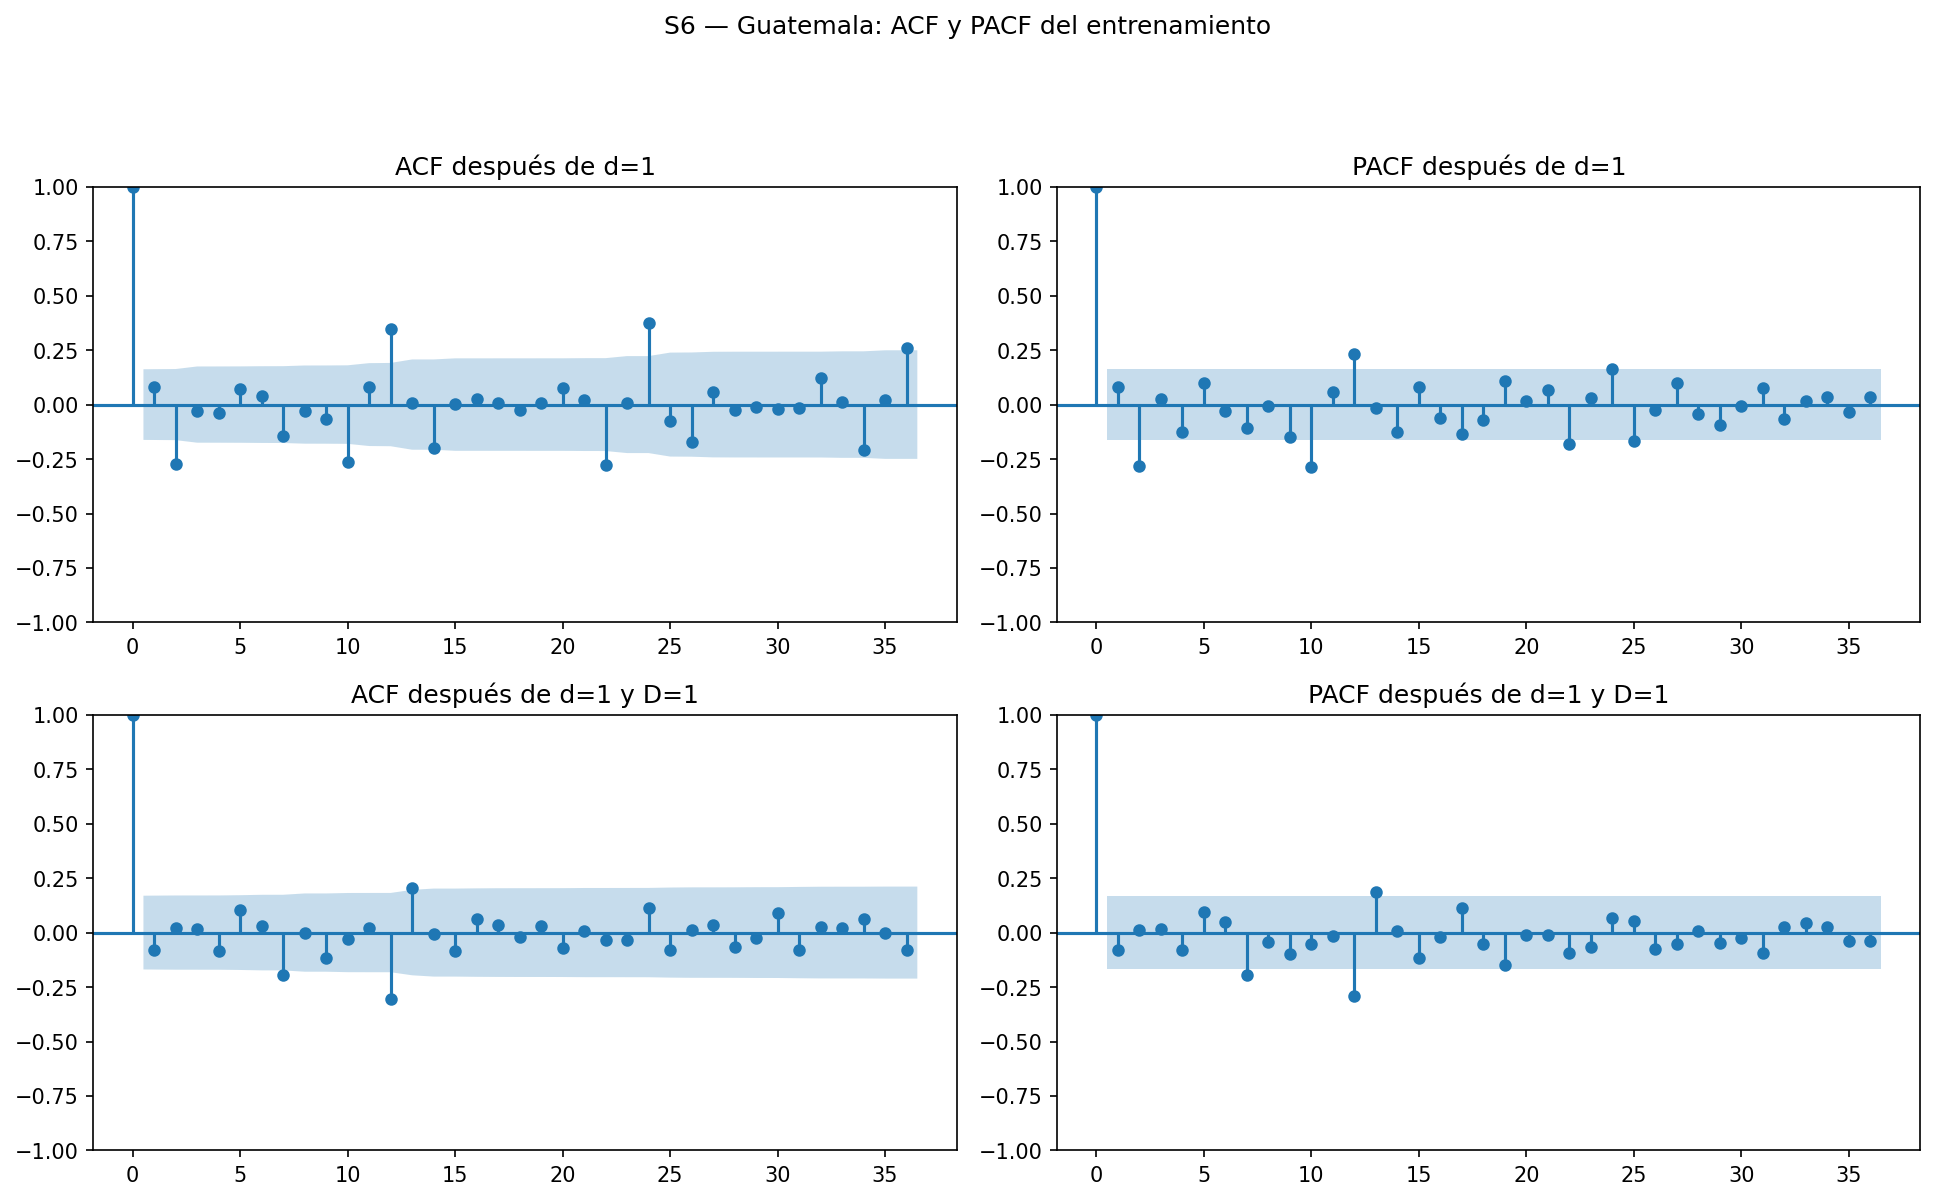

In [17]:
display(
    estacionariedad.loc[
        estacionariedad["serie"] == "S6_guatemala",
        ["transformacion", "p_ADF", "p_KPSS", "veredicto"],
    ].round(4)
)
display(Image(filename=str(DIR_IMG / "s6_acf_pacf.png")))

### SARIMA(1,1,1)(0,1,1,12) es el mejor por RMSE, aunque no por AIC ni por MAE

SARIMA(1,1,1)(0,1,1,12) obtiene el menor RMSE (47,260) entre
todos los candidatos, con MAE de 27,317. El MAPE de
66.2% se calcula únicamente sobre los 21 meses de prueba con
valor distinto de cero; los 42 meses en cero quedan fuera del cálculo porque
dividir entre cero no está definido, y ese es exactamente el comportamiento
esperado del MAPE seguro usado en este proyecto. Ni el modelo con menor AIC
(`auto_arima(1,0,1)(1,0,1,12)`, AIC=2.27) ni el de menor MAE
(SARIMA(2,1,1)(1,1,0,12), MAE=24,440) coinciden con el modelo de menor RMSE:
ambos tienen un RMSE ligeramente superior. Esto refuerza que ningún criterio
por sí solo basta para elegir el mejor modelo.

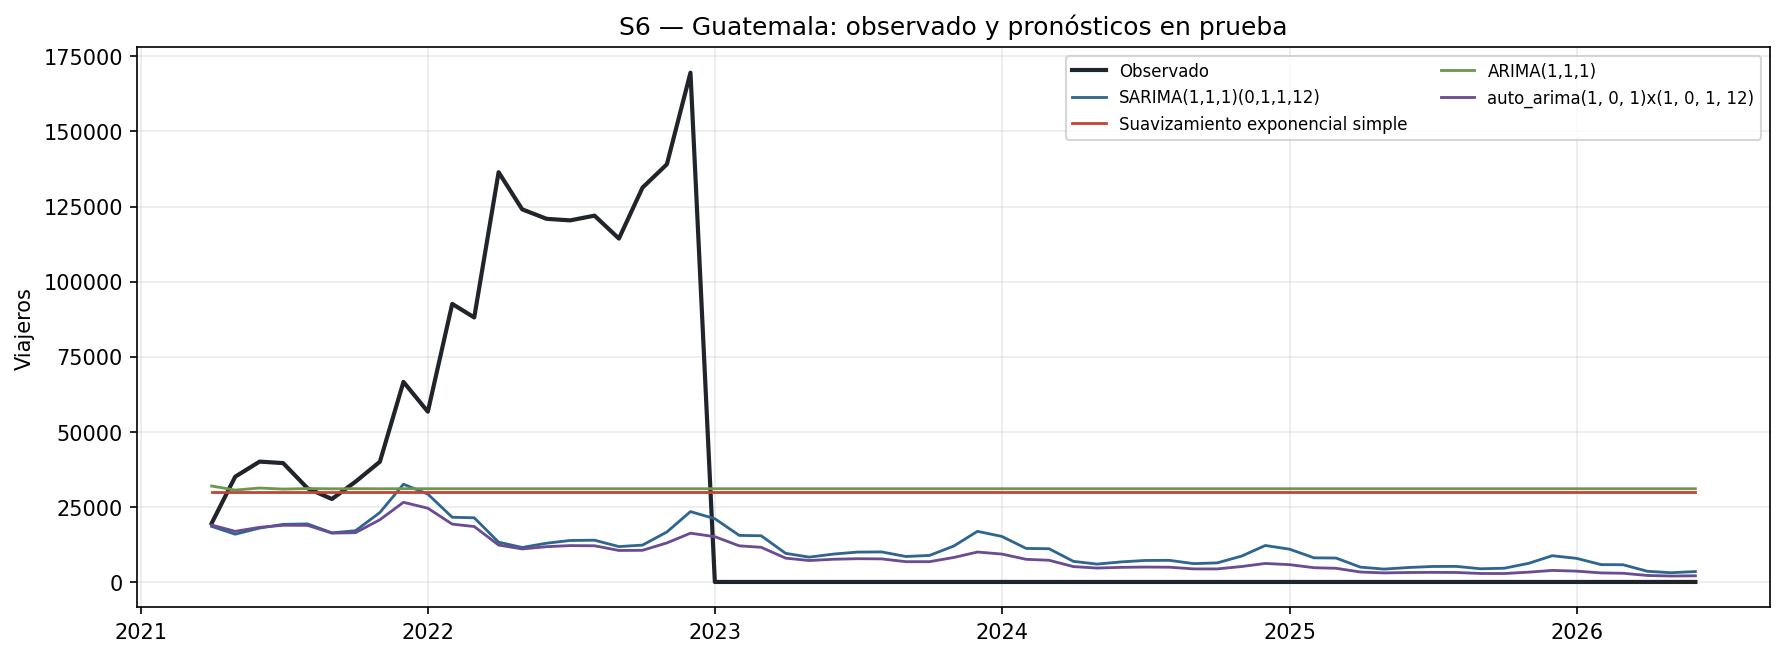

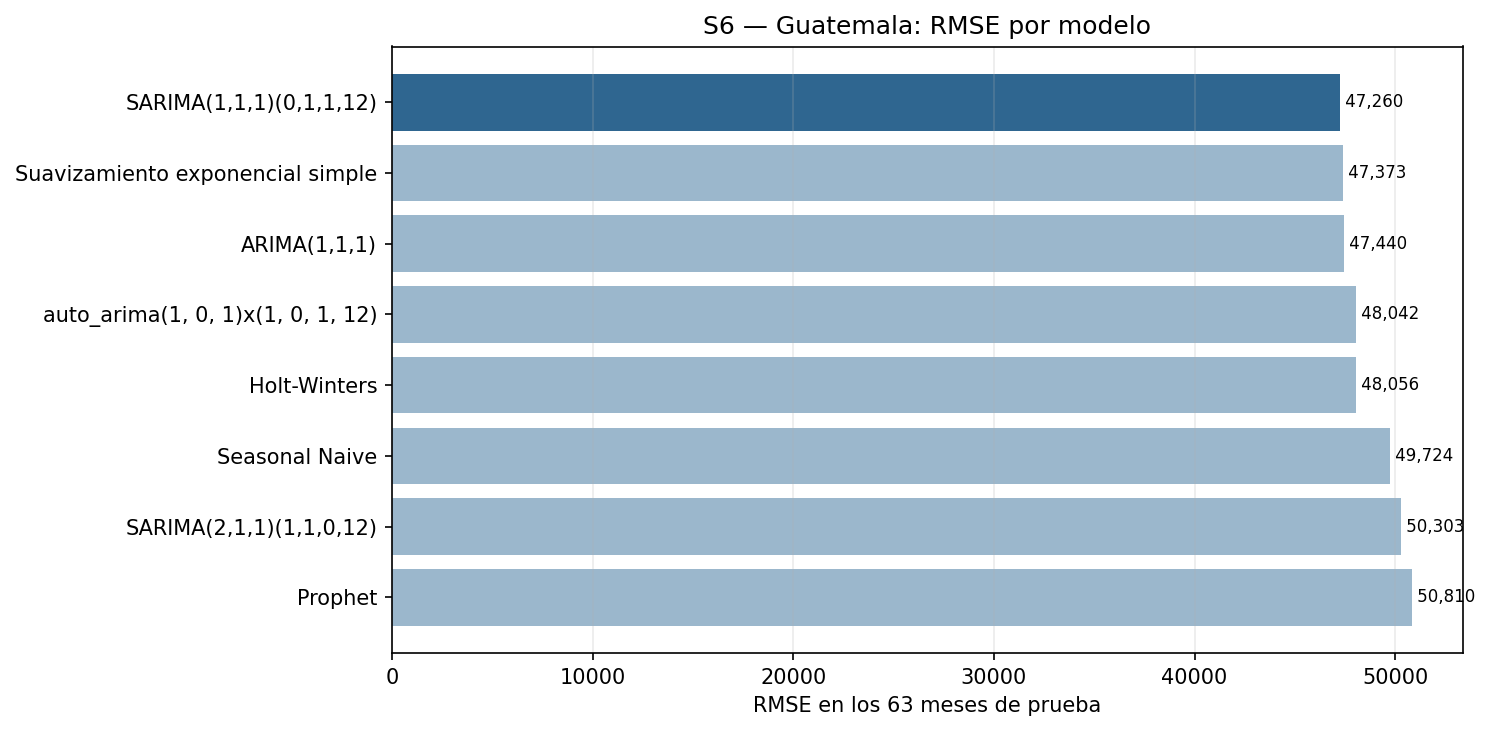

,serie,modelo,parametros,transformacion,AIC,BIC,MAE,RMSE,MAPE,Ljung_Box_p,Jarque_Bera_p,mejor_modelo
18,S6_guatemala,"SARIMA(1,1,1)(0,1,1,12)","{'orden': (1, 1, 1), 'orden_estacional': (0, 1...",log1p,13.42,24.57,27316.84,47260.25,66.22,0.0653,0.000000e+00,True
19,S6_guatemala,Suavizamiento exponencial simple,"{'tendencia': None, 'estacionalidad': None}",ninguna,NaN,NaN,38141.15,47372.94,52.04,0.0000,2.248040e-04,False
20,S6_guatemala,"ARIMA(1,1,1)","{'orden': (1, 1, 1), 'orden_estacional': (0, 0...",log1p,38.66,47.57,38591.90,47439.93,51.24,0.0025,2.623202e-167,False
21,S6_guatemala,"auto_arima(1, 0, 1)x(1, 0, 1, 12)","{'orden': (1, 0, 1), 'orden_estacional': (1, 0...",log1p,2.27,16.72,26049.66,48042.48,68.23,0.0268,0.000000e+00,False
22,S6_guatemala,Holt-Winters,"{'tendencia': 'aditiva amortiguada', 'estacion...",ninguna,NaN,NaN,39202.95,48055.85,48.43,0.1653,1.681163e-161,False
23,S6_guatemala,Seasonal Naive,{'rezago': 12},ninguna,NaN,NaN,35468.91,49723.65,70.08,0.0000,1.917958e-70,False
24,S6_guatemala,"SARIMA(2,1,1)(1,1,0,12)","{'orden': (2, 1, 1), 'orden_estacional': (1, 1...",log1p,10.47,24.41,24439.69,50303.05,67.07,0.2128,0.000000e+00,False
25,S6_guatemala,Prophet,"{'crecimiento': 'linear', 'estacionalidad_anua...",ninguna,NaN,NaN,48592.78,50809.96,80.15,0.0000,2.950024e-07,False


In [18]:
display(Image(filename=str(DIR_IMG / "s6_pronosticos.png")))
display(Image(filename=str(DIR_IMG / "s6_rmse_modelos.png")))
display(
    metricas.loc[metricas["serie"] == "S6_guatemala"].round({
        "AIC": 2, "BIC": 2, "MAE": 2, "RMSE": 2,
        "MAPE": 2, "Ljung_Box_p": 4,
    })
)

### El diagnóstico es aceptable, pero ningún modelo anticipó los ceros de 2023

El candidato elegido obtiene `p=0.065` en Ljung-Box, sin rechazar la ausencia
de autocorrelación al 5%, aunque cerca del umbral. Ningún modelo de la
comparación fue diseñado para anticipar que Guatemala dejaría de reportarse
como país individual: todos pronostican valores positivos donde la serie real
vale cero desde 2023, lo que infla el error de los últimos 42 meses de prueba
para cualquier candidato. Esta limitación debe explicarse junto con las
métricas de S6 y no atribuirse a una falla real de turismo.

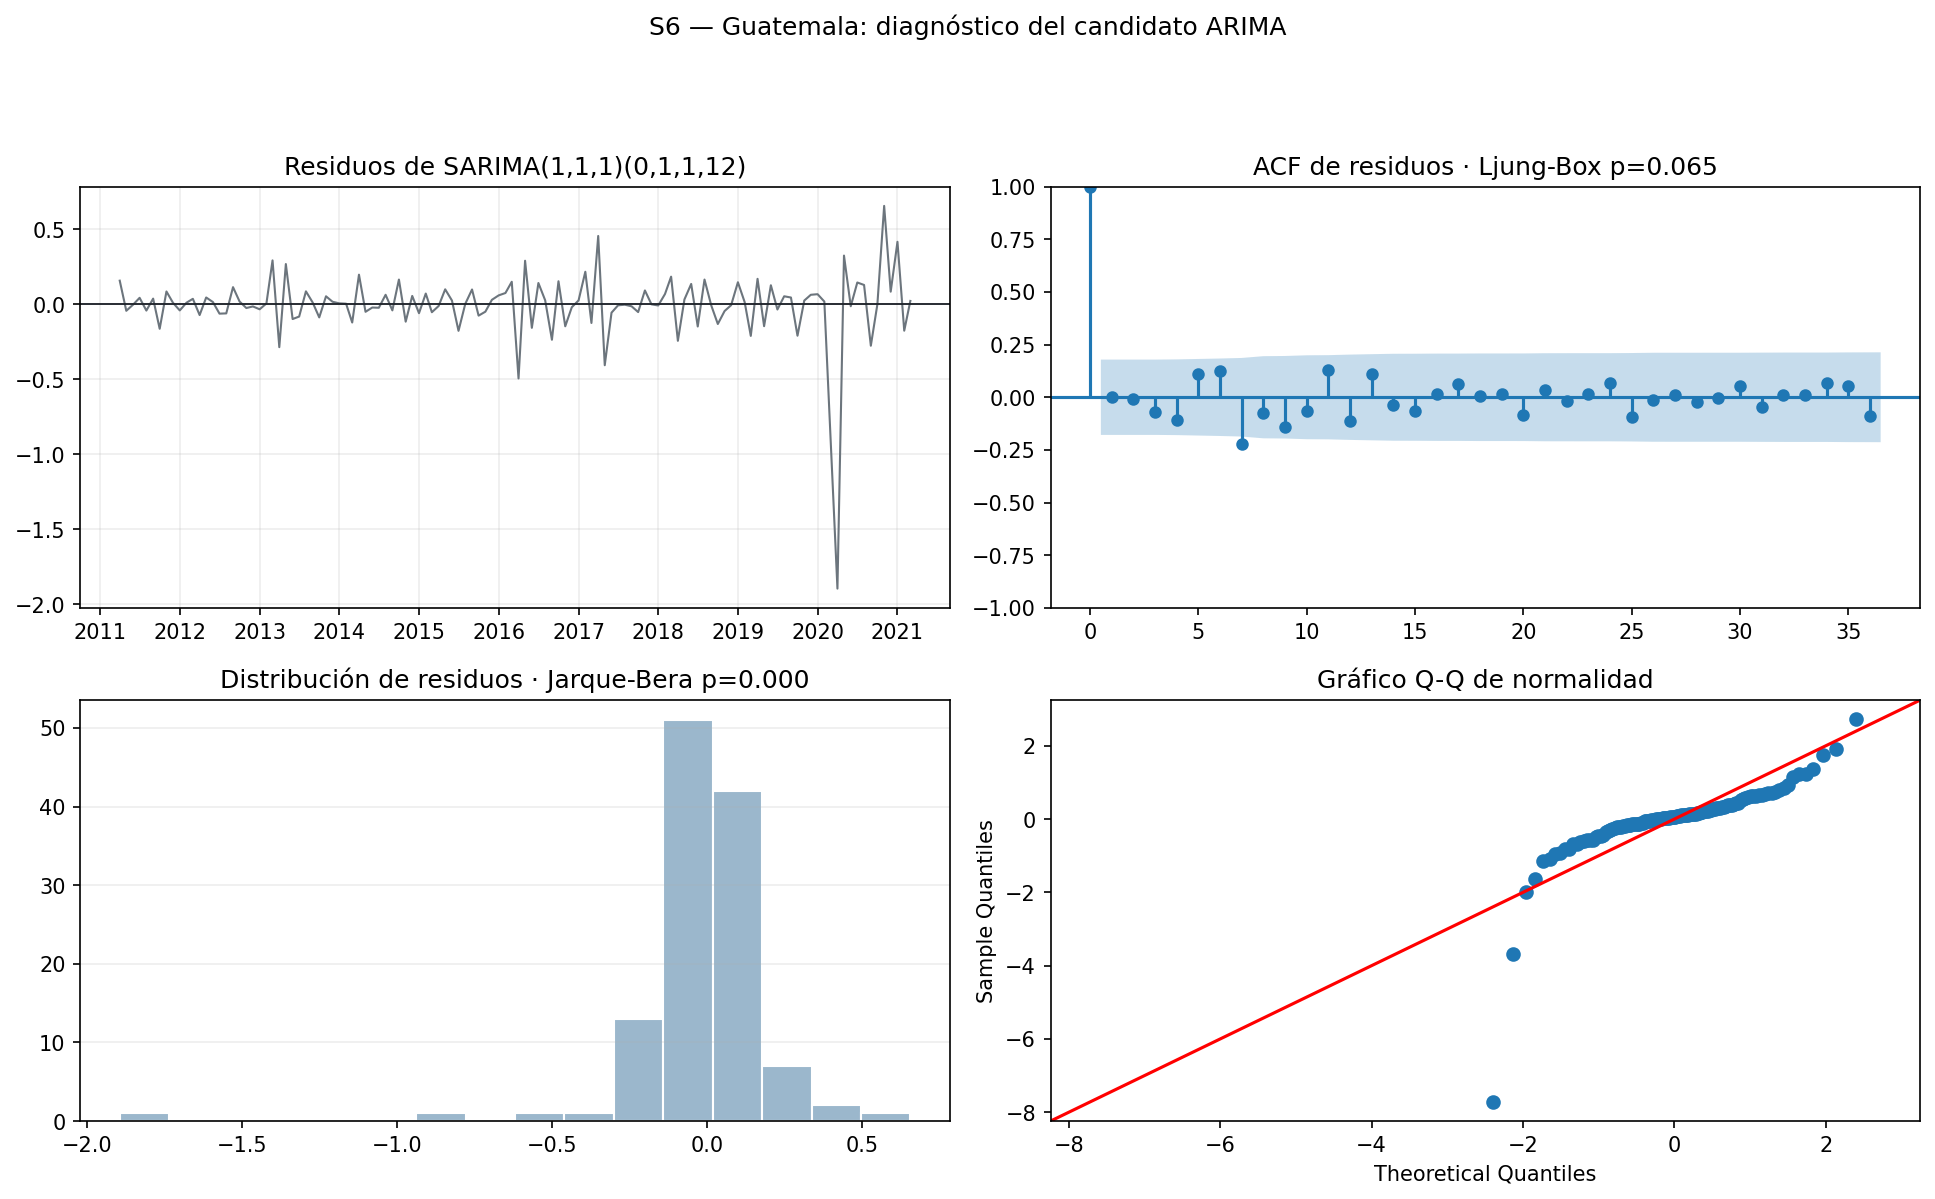

In [19]:
display(Image(filename=str(DIR_IMG / "s6_residuos.png")))

## Conclusiones del modelado

- Las tres series usan la misma partición 147/63 y el mismo contrato técnico
  que S0 y S5: ARIMA/SARIMA manuales, `auto_arima` acotado, Prophet,
  Holt-Winters, suavizamiento simple y Seasonal Naive, con MAE/RMSE sobre los
  63 meses de prueba y AIC/BIC solo para ARIMA/SARIMA.
- S1 y S2 tienen tendencia dominante y estacionalidad moderada; ninguna tiene
  ceros. S1 es más estacional (0.559) que S2 (0.311), consistente
  con la diferencia entre tráfico aéreo y terrestre.
- En S1, ARIMA(1,1,1) fue el más preciso; en S2, Prophet. En ambos casos el
  mejor RMSE no coincidió con el menor AIC entre los candidatos ARIMA/SARIMA,
  y en S1 un candidato con AIC competitivo produjo un pronóstico
  numéricamente inestable que se documentó en vez de ocultarse.
- S6 exige una lectura distinta: sus 42 ceros de prueba desde 2023 son un
  artefacto de la granularidad de `País`, no una caída real, y la serie
  describe sobre todo retorno de residentes guatemaltecos. `log1p` permite
  ajustar y pronosticar sin distorsionar esos ceros, y el MAPE reportado
  ignora esos meses por construcción.
- Las tablas homogéneas de S1, S2 y S6 quedan en
  `data/processed/resultados/metricas_s1_s2_s6.csv`, junto con
  `estacionariedad_s1_s2_s6.csv`, `pronosticos_s1_s2_s6.csv` y
  `resumen_s1_s2_s6.json`. El comparativo final de Fronteras (S1, S2, S3)
  se desarrolla en `03_series_fronteras.ipynb`; S6 se conserva como insumo
  posterior para el comparativo de Países (S4, S5, S6).
- Los adaptadores de Holt-Winters, suavizamiento simple y Seasonal Naive
  mantienen la misma partición, horizonte y contrato de métricas que los
  modelos ARIMA/SARIMA y Prophet.